<a href="https://colab.research.google.com/github/milkpotato1000/bigCon_hom/blob/jin2/bigcon_jin1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 분석 개요

분석 목표 등 요약
- 주제 : 미래를 예측하는 데이터 챌린지 -- 우리 동네 가맹점, 위기 신호를 미리 잡아라!
(영세/중소 요식 가맹업 경영 위기 조기 경보 시스템 제안)
- 가맹점이 갑자기 어려워지는 순간(매출 급락, 폐업 위험 등)을 미리 감지할수 있는 'AI 조기 경보 시스템 제안'
- 데이터에서 어떤 신호가 위기를 미리 알려주는지 직접 찾아내고, 이 결과를 소상공인이 활용할 수 있는 아이디어도 제안



"이번 빅콘테스트에 제공된 데이터 모수는 '25 하반기 기준 영세, 중소 가맹점 기준입니다."
데이터 전처리 과정 중 '24년 매출 기준 국세청 데이터를 '25 하반기 카드사 가맹점 정보와 매칭 과정에서 폐업된 가맹점은 제외되어 산출됩니다.
"따라서 데이터 분석은 주어진 '23.1~'24.12 데이터를 기반으로 '25.7월 이후 가맹점이 어려워지는 순간(폐업, 매출 급락) 을 감지할 수 있는 'AI 조기 경보 시스템'을 제안해주시면 됩니다."
```


데이터 정의서 등 참고 문서
- https://docs.google.com/spreadsheets/d/1Xepbio9MctRbELhnMcaqg9ln--wRQMYTL5g0wgS02wc/edit?gid=1092014041#gid=1092014041

# 데이터 로드

In [2]:
import numpy as np
import pandas as pd
import os

# 코랩 구글 드라이브용 경로
try:
    df1 = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/big_data_set1_f.csv', encoding='cp949')
    df2 = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/big_data_set2_f.csv', encoding='cp949')
    df3 = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/big_data_set3_f.csv', encoding='cp949')
except UnicodeDecodeError:
    print("Could not decode using cp949, trying utf-8")
    df1 = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/big_data_set1_f.csv', encoding='utf-8')
    df2 = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/big_data_set2_f.csv', encoding='utf-8')
    df3 = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/big_data_set3_f.csv', encoding='utf-8')


# 로컬용 경로

# 캐글용 경로
# train_df = pd.read_csv('/kaggle/input/modu-ds-5-house-prices-prediction/train.csv')
# test_df = pd.read_csv('/kaggle/input/modu-ds-5-house-prices-prediction/test.csv')

# EDA

In [3]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4185 entries, 0 to 4184
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ENCODED_MCT         4185 non-null   object 
 1   MCT_BSE_AR          4185 non-null   object 
 2   MCT_NM              4185 non-null   object 
 3   MCT_BRD_NUM         542 non-null    object 
 4   MCT_SIGUNGU_NM      4185 non-null   object 
 5   HPSN_MCT_ZCD_NM     4185 non-null   object 
 6   HPSN_MCT_BZN_CD_NM  3138 non-null   object 
 7   ARE_D               4185 non-null   int64  
 8   MCT_ME_D            127 non-null    float64
dtypes: float64(1), int64(1), object(7)
memory usage: 294.4+ KB


In [4]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 86590 entries, 0 to 86589
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ENCODED_MCT             86590 non-null  object 
 1   TA_YM                   86590 non-null  int64  
 2   MCT_OPE_MS_CN           86590 non-null  object 
 3   RC_M1_SAA               86590 non-null  object 
 4   RC_M1_TO_UE_CT          86590 non-null  object 
 5   RC_M1_UE_CUS_CN         86590 non-null  object 
 6   RC_M1_AV_NP_AT          86590 non-null  object 
 7   APV_CE_RAT              79958 non-null  object 
 8   DLV_SAA_RAT             86590 non-null  float64
 9   M1_SME_RY_SAA_RAT       86590 non-null  float64
 10  M1_SME_RY_CNT_RAT       86590 non-null  float64
 11  M12_SME_RY_SAA_PCE_RT   86590 non-null  float64
 12  M12_SME_BZN_SAA_PCE_RT  86590 non-null  float64
 13  M12_SME_RY_ME_MCT_RAT   86590 non-null  float64
 14  M12_SME_BZN_ME_MCT_RAT  86590 non-null

In [5]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 86590 entries, 0 to 86589
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ENCODED_MCT               86590 non-null  object 
 1   TA_YM                     86590 non-null  int64  
 2   M12_MAL_1020_RAT          86590 non-null  float64
 3   M12_MAL_30_RAT            86590 non-null  float64
 4   M12_MAL_40_RAT            86590 non-null  float64
 5   M12_MAL_50_RAT            86590 non-null  float64
 6   M12_MAL_60_RAT            86590 non-null  float64
 7   M12_FME_1020_RAT          86590 non-null  float64
 8   M12_FME_30_RAT            86590 non-null  float64
 9   M12_FME_40_RAT            86590 non-null  float64
 10  M12_FME_50_RAT            86590 non-null  float64
 11  M12_FME_60_RAT            86590 non-null  float64
 12  MCT_UE_CLN_REU_RAT        86590 non-null  float64
 13  MCT_UE_CLN_NEW_RAT        86590 non-null  float64
 14  RC_M1_

In [6]:
df1.head(5)

,ENCODED_MCT,MCT_BSE_AR,MCT_NM,MCT_BRD_NUM,MCT_SIGUNGU_NM,HPSN_MCT_ZCD_NM,HPSN_MCT_BZN_CD_NM,ARE_D,MCT_ME_D
0,16184E93D9,서울 성동구 마장동,성우**,NaN,서울 성동구,축산물,마장동,20130320,NaN
1,4D039EA8B7,서울 성동구 마장동,대보**,NaN,서울 성동구,축산물,마장동,20131122,NaN
2,0074C4990A,서울 성동구 마장동,대용**,NaN,서울 성동구,축산물,마장동,20140512,NaN
3,68308F2746,서울 성동구 마장동,통일**,NaN,서울 성동구,축산물,마장동,20151124,NaN
4,4117EDDE9C,서울 성동구 마장동,한울**,NaN,서울 성동구,축산물,마장동,20151211,NaN


In [7]:
df2.head(5)

,ENCODED_MCT,TA_YM,MCT_OPE_MS_CN,RC_M1_SAA,RC_M1_TO_UE_CT,RC_M1_UE_CUS_CN,RC_M1_AV_NP_AT,APV_CE_RAT,DLV_SAA_RAT,M1_SME_RY_SAA_RAT,M1_SME_RY_CNT_RAT,M12_SME_RY_SAA_PCE_RT,M12_SME_BZN_SAA_PCE_RT,M12_SME_RY_ME_MCT_RAT,M12_SME_BZN_ME_MCT_RAT
0,000F03E44A,202404,4_50-75%,5_75-90%,5_75-90%,5_75-90%,5_75-90%,1_상위1구간,-999999.9,2.6,10.6,93.8,71.5,16.7,7.8
1,000F03E44A,202312,4_50-75%,6_90%초과(하위 10% 이하),6_90%초과(하위 10% 이하),6_90%초과(하위 10% 이하),6_90%초과(하위 10% 이하),NaN,-999999.9,0.0,0.0,94.8,73.4,16.6,7.2
2,002816BA73,202404,2_10-25%,3_25-50%,4_50-75%,4_50-75%,2_10-25%,6_상위6구간(하위1구간),-999999.9,96.6,40.8,15.6,20.0,17.5,5.2
3,002816BA73,202411,2_10-25%,3_25-50%,4_50-75%,4_50-75%,2_10-25%,6_상위6구간(하위1구간),-999999.9,108.0,46.4,16.8,19.8,16.9,6.9
4,002816BA73,202406,2_10-25%,4_50-75%,4_50-75%,4_50-75%,2_10-25%,1_상위1구간,-999999.9,74.2,38.1,16.0,19.9,17.3,5.6


In [8]:
df3.head(5)

,ENCODED_MCT,TA_YM,M12_MAL_1020_RAT,M12_MAL_30_RAT,M12_MAL_40_RAT,M12_MAL_50_RAT,M12_MAL_60_RAT,M12_FME_1020_RAT,M12_FME_30_RAT,M12_FME_40_RAT,M12_FME_50_RAT,M12_FME_60_RAT,MCT_UE_CLN_REU_RAT,MCT_UE_CLN_NEW_RAT,RC_M1_SHC_RSD_UE_CLN_RAT,RC_M1_SHC_WP_UE_CLN_RAT,RC_M1_SHC_FLP_UE_CLN_RAT
0,0305234DDB,202311,0.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100.00,0.0,-999999.9,-999999.9,-999999.9
1,0495B069FF,202403,0.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,25.00,25.0,0.0,0.0,100.0
2,0495B069FF,202405,0.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,33.33,0.0,-999999.9,-999999.9,-999999.9
3,0495B069FF,202406,0.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,33.33,0.0,-999999.9,-999999.9,-999999.9
4,055EDDDD01,202410,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100.0,0.0,33.33,0.0,-999999.9,-999999.9,-999999.9


In [9]:
df1['MCT_BSE_AR'].value_counts()

,count
MCT_BSE_AR,
서울특별시 성동구 왕십리로 410,73
서울특별시 성동구 마장로 137,38
서울특별시 성동구 왕십리광장로 17,31
서울 성동구 마장동,21
서울특별시 성동구 무학로6길 50,18
...,...
서울특별시 성동구 장터길 45,1
서울특별시 성동구 장터길 47,1
서울특별시 성동구 행당로 43,1


In [10]:
df1['HPSN_MCT_BZN_CD_NM'].value_counts()

,count
HPSN_MCT_BZN_CD_NM,
성수,762
왕십리,538
뚝섬,468
한양대,328
마장동,257
금남시장,249
답십리,179
옥수,121
신금호,100


In [11]:
df2['MCT_OPE_MS_CN'].value_counts()

,count
MCT_OPE_MS_CN,
3_25-50%,21812
4_50-75%,21567
5_75-90%,13454
2_10-25%,13119
1_10%이하,8691
6_90%초과(하위 10% 이하),7947


### df1 형별

In [12]:
object_columns = df1.select_dtypes(include='object').columns.tolist()
numeric_columns = df1.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("Object Columns:", object_columns)
print("Numeric Columns:", numeric_columns)

Object Columns: ['ENCODED_MCT', 'MCT_BSE_AR', 'MCT_NM', 'MCT_BRD_NUM', 'MCT_SIGUNGU_NM', 'HPSN_MCT_ZCD_NM', 'HPSN_MCT_BZN_CD_NM']
Numeric Columns: ['ARE_D', 'MCT_ME_D']


/tmp/ipython-input-2871951054.py:18: UserWarning: Glyph 49436 (\N{HANGUL SYLLABLE SEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2871951054.py:18: UserWarning: Glyph 50872 (\N{HANGUL SYLLABLE UL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2871951054.py:18: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2871951054.py:18: UserWarning: Glyph 46041 (\N{HANGUL SYLLABLE DONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2871951054.py:18: UserWarning: Glyph 44396 (\N{HANGUL SYLLABLE GU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2871951054.py:18: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2871951054.py:18: UserWarning: Glyph 50773 (\N{HANGUL SYLLABLE WANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(

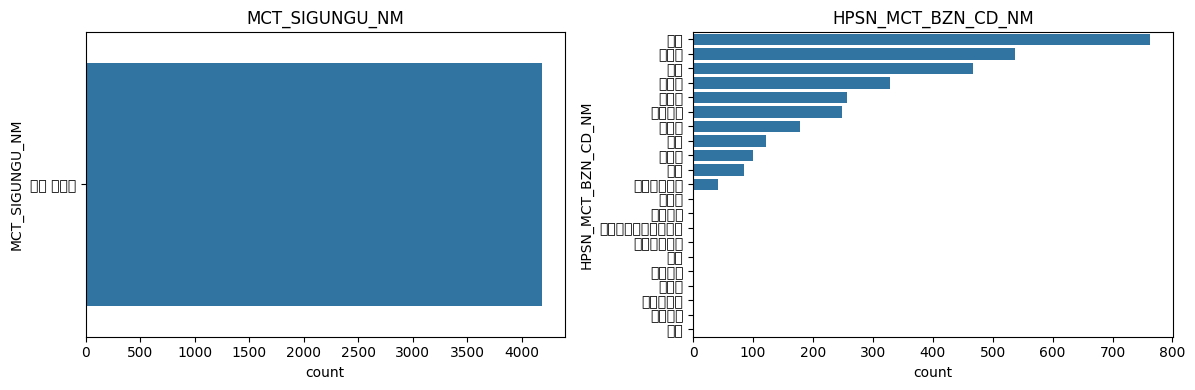

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter out columns with too many unique values for plotting
object_columns_to_plot = [col for col in object_columns if df1[col].nunique() <= 50]

# Determine the number of rows and columns for subplots
n_cols = 3
n_rows = (len(object_columns_to_plot) + n_cols - 1) // n_cols

plt.figure(figsize=(n_cols * 6, n_rows * 4))

for i, col in enumerate(object_columns_to_plot):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.countplot(y=col, data=df1, order=df1[col].value_counts().index)
    plt.title(col)

plt.tight_layout()
plt.show()

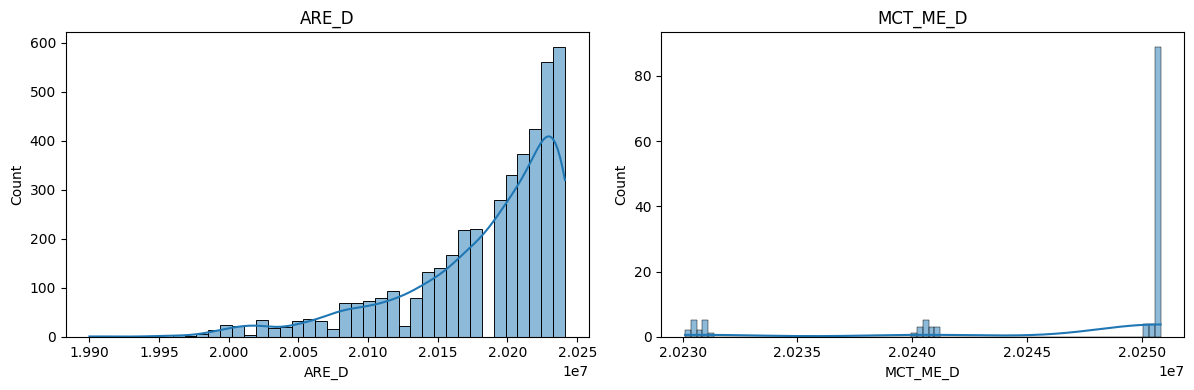

In [14]:
n_cols = 3
n_rows = (len(numeric_columns) + n_cols - 1) // n_cols

plt.figure(figsize=(n_cols * 6, n_rows * 4))

for i, col in enumerate(numeric_columns):
    plt.subplot(n_rows, n_cols, i + 1)
    if df1[col].nunique() > 50:  # Use histogram for columns with many unique values
        sns.histplot(data=df1, x=col, kde=True)
    else:  # Use countplot or barplot for columns with few unique values
        sns.countplot(data=df1, y=col, order=df1[col].value_counts().index)
    plt.title(col)

plt.tight_layout()
plt.show()

### df2 형별

In [15]:
df2_object_columns = df2.select_dtypes(include='object').columns.tolist()
df2_numeric_columns = df2.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("df2 Object Columns:", df2_object_columns)
print("df2 Numeric Columns:", df2_numeric_columns)

df2 Object Columns: ['ENCODED_MCT', 'MCT_OPE_MS_CN', 'RC_M1_SAA', 'RC_M1_TO_UE_CT', 'RC_M1_UE_CUS_CN', 'RC_M1_AV_NP_AT', 'APV_CE_RAT']
df2 Numeric Columns: ['TA_YM', 'DLV_SAA_RAT', 'M1_SME_RY_SAA_RAT', 'M1_SME_RY_CNT_RAT', 'M12_SME_RY_SAA_PCE_RT', 'M12_SME_BZN_SAA_PCE_RT', 'M12_SME_RY_ME_MCT_RAT', 'M12_SME_BZN_ME_MCT_RAT']


NanumGothic font not found.


/tmp/ipython-input-4034694162.py:40: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-4034694162.py:40: UserWarning: Glyph 54616 (\N{HANGUL SYLLABLE HA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-4034694162.py:40: UserWarning: Glyph 52488 (\N{HANGUL SYLLABLE CO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-4034694162.py:40: UserWarning: Glyph 44284 (\N{HANGUL SYLLABLE GWA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-4034694162.py:40: UserWarning: Glyph 50948 (\N{HANGUL SYLLABLE WI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-4034694162.py:40: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-4034694162.py:40: UserWarning: Glyph 44396 (\N{HANGUL SYLLABLE GU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp

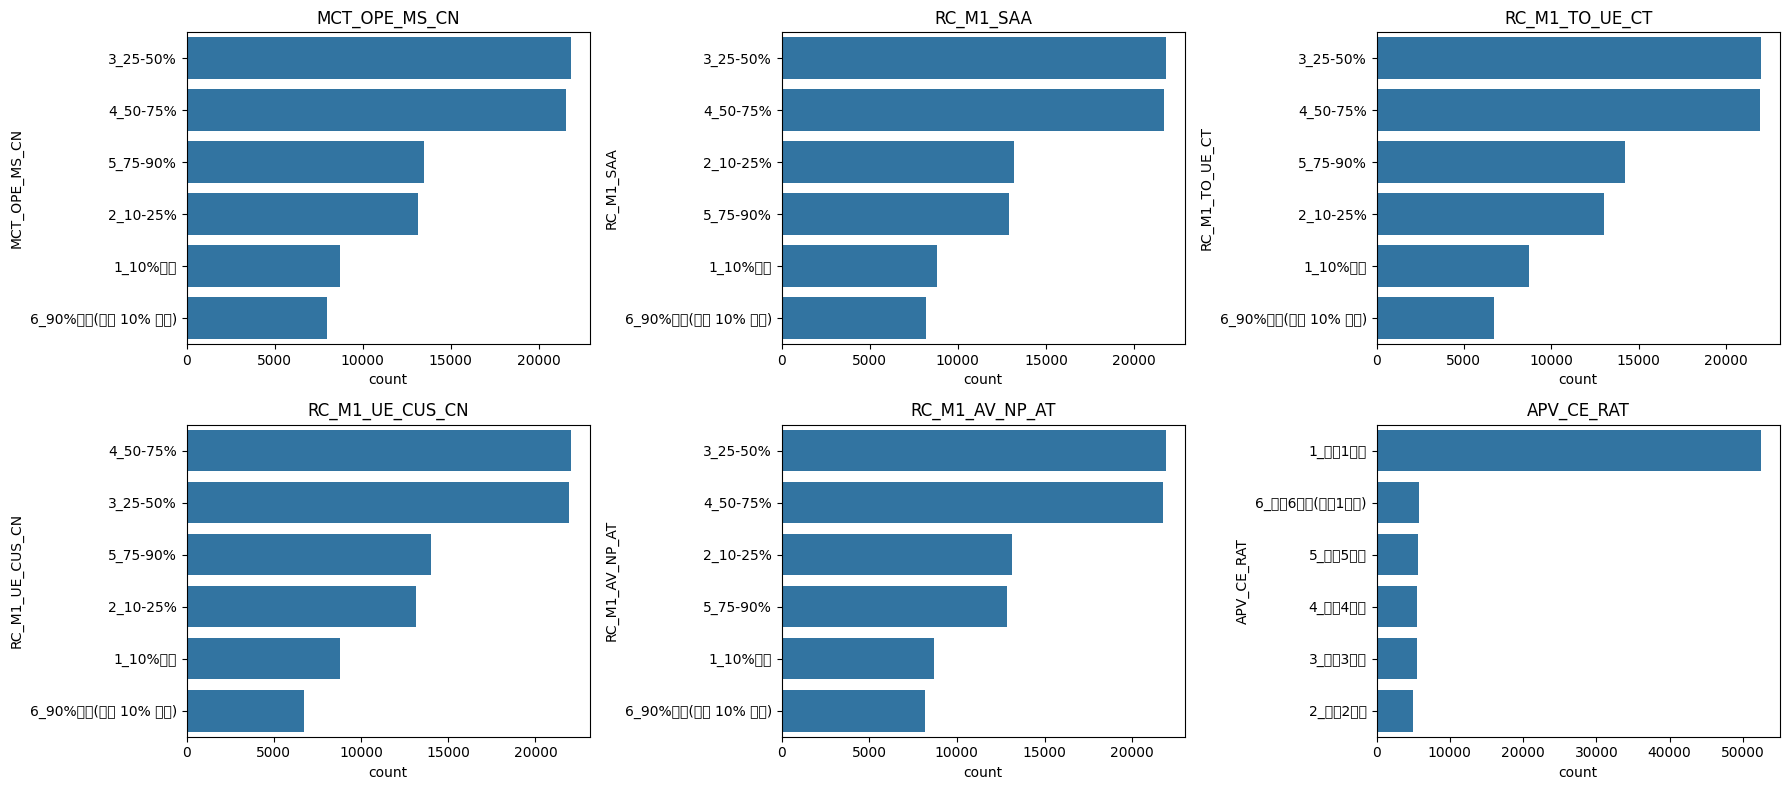

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm
import os

# Find the Nanum font file
nanum_font_path = None
for font_path in fm.findSystemFonts(fontpaths=None, fontext='ttf'):
    if 'NanumGothic' in font_path:
        nanum_font_path = font_path
        break

if nanum_font_path:
    # Add the font to matplotlib's font manager
    fm.fontManager.addfont(nanum_font_path)
    plt.rcParams['font.family'] = 'NanumGothic'
    plt.rcParams['axes.unicode_minus'] = False
    print(f"Using font: {plt.rcParams['font.family']}")
else:
    print("NanumGothic font not found.")
    # Fallback to a default font if NanumGothic is not found
    plt.rcParams['font.family'] = 'DejaVu Sans'
    plt.rcParams['axes.unicode_minus'] = True


# Filter out columns with too many unique values for plotting
df2_object_columns_to_plot = [col for col in df2_object_columns if df2[col].nunique() <= 50]

# Determine the number of rows and columns for subplots
n_cols = 3
n_rows = (len(df2_object_columns_to_plot) + n_cols - 1) // n_cols

plt.figure(figsize=(n_cols * 6, n_rows * 4))

for i, col in enumerate(df2_object_columns_to_plot):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.countplot(y=col, data=df2, order=df2[col].value_counts().index)
    plt.title(col)

plt.tight_layout()
plt.show()

In [17]:
# import matplotlib.pyplot as plt
# import seaborn as sns
# import matplotlib.font_manager as fm

# # Find available Korean fonts and set font
# font_list = fm.findSystemFonts(fontpaths=None, fontext='ttf')
# korean_font_list = [f for f in font_list if 'Nanum' in f or 'Malgun' in f]

# if len(korean_font_list) > 0:
#     # Use the first found Korean font
#     plt.rcParams['font.family'] = fm.FontProperties(fname=korean_font_list[0]).get_name()
#     plt.rcParams['axes.unicode_minus'] = False
#     print(f"Using font: {plt.rcParams['font.family']}")
# else:
#     print("No Korean fonts found on the system.")
#     # Fallback to a default font if no Korean font is found
#     plt.rcParams['font.family'] = 'DejaVu Sans'
#     plt.rcParams['axes.unicode_minus'] = True

# # Identify numeric columns in df2 (assuming df2_numeric_columns is already defined)
# df2_numeric_columns = df2.select_dtypes(include=['int64', 'float64']).columns.tolist()

# n_cols = 3
# n_rows = (len(df2_numeric_columns) + n_cols - 1) // n_cols

# plt.figure(figsize=(n_cols * 6, n_rows * 4))

# for i, col in enumerate(df2_numeric_columns):
#     plt.subplot(n_rows, n_cols, i + 1)
#     if df2[col].nunique() > 50:  # Use histogram for columns with many unique values
#         sns.histplot(data=df2, x=col, kde=True)
#     else:  # Use countplot or barplot for columns with few unique values
#         sns.countplot(data=df2, y=col, order=df2[col].value_counts().index)
#     plt.title(col)

# plt.tight_layout()
# plt.show()

### df3 형별

In [18]:
df3_object_columns = df3.select_dtypes(include='object').columns.tolist()
df3_numeric_columns = df3.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("df3 Object Columns:", df3_object_columns)
print("df3 Numeric Columns:", df3_numeric_columns)

df3 Object Columns: ['ENCODED_MCT']
df3 Numeric Columns: ['TA_YM', 'M12_MAL_1020_RAT', 'M12_MAL_30_RAT', 'M12_MAL_40_RAT', 'M12_MAL_50_RAT', 'M12_MAL_60_RAT', 'M12_FME_1020_RAT', 'M12_FME_30_RAT', 'M12_FME_40_RAT', 'M12_FME_50_RAT', 'M12_FME_60_RAT', 'MCT_UE_CLN_REU_RAT', 'MCT_UE_CLN_NEW_RAT', 'RC_M1_SHC_RSD_UE_CLN_RAT', 'RC_M1_SHC_WP_UE_CLN_RAT', 'RC_M1_SHC_FLP_UE_CLN_RAT']


In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter out columns with too many unique values for plotting
df3_object_columns_to_plot = [col for col in df3_object_columns if df3[col].nunique() <= 50]

# Determine the number of rows and columns for subplots
n_cols = 3
n_rows = (len(df3_object_columns_to_plot) + n_cols - 1) // n_cols

plt.figure(figsize=(n_cols * 6, n_rows * 4))

for i, col in enumerate(df3_object_columns_to_plot):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.countplot(y=col, data=df3, order=df3[col].value_counts().index)
    plt.title(col)

plt.tight_layout()
plt.show()

<Figure size 1800x0 with 0 Axes>

In [20]:
# import matplotlib.pyplot as plt
# import seaborn as sns

# # Identify numeric columns in df3 (assuming df3_numeric_columns is already defined)
# df3_numeric_columns = df3.select_dtypes(include=['int64', 'float64']).columns.tolist()


# n_cols = 3
# n_rows = (len(df3_numeric_columns) + n_cols - 1) // n_cols

# plt.figure(figsize=(n_cols * 6, n_rows * 4))

# for i, col in enumerate(df3_numeric_columns):
#     plt.subplot(n_rows, n_cols, i + 1)
#     if df3[col].nunique() > 50:  # Use histogram for columns with many unique values
#         sns.histplot(data=df3, x=col, kde=True)
#     else:  # Use countplot or barplot for columns with few unique values
#         sns.countplot(data=df3, y=col, order=df3[col].value_counts().index)
#     plt.title(col)

# plt.tight_layout()
# plt.show()

## 결측치 확인

In [21]:
# Check for missing values in df1 and calculate the percentage
missing_df1 = df1.isnull().sum()
missing_percent_df1 = (missing_df1 / len(df1)) * 100
missing_info_df1 = pd.DataFrame({'Missing Count': missing_df1, 'Missing Percentage': missing_percent_df1})
missing_info_df1 = missing_info_df1[missing_info_df1['Missing Count'] > 0].sort_values(by='Missing Percentage', ascending=False)

# Check for missing values in df2 and calculate the percentage
missing_df2 = df2.isnull().sum()
missing_percent_df2 = (missing_df2 / len(df2)) * 100
missing_info_df2 = pd.DataFrame({'Missing Count': missing_df2, 'Missing Percentage': missing_percent_df2})
missing_info_df2 = missing_info_df2[missing_info_df2['Missing Count'] > 0].sort_values(by='Missing Percentage', ascending=False)

# Check for missing values in df3 and calculate the percentage
missing_df3 = df3.isnull().sum()
missing_percent_df3 = (missing_df3 / len(df3)) * 100
missing_info_df3 = pd.DataFrame({'Missing Count': missing_df3, 'Missing Percentage': missing_percent_df3})
missing_info_df3 = missing_info_df3[missing_info_df3['Missing Count'] > 0].sort_values(by='Missing Percentage', ascending=False)

print("Missing values in df1:")
display(missing_info_df1)

print("\nMissing values in df2:")
display(missing_info_df2)

print("\nMissing values in df3:")
display(missing_info_df3)

Missing values in df1:


,Missing Count,Missing Percentage
MCT_ME_D,4058,96.965352
MCT_BRD_NUM,3643,87.048984
HPSN_MCT_BZN_CD_NM,1047,25.017921



Missing values in df2:


,Missing Count,Missing Percentage
APV_CE_RAT,6632,7.659083



Missing values in df3:


,Missing Count,Missing Percentage


No Korean fonts found on the system.


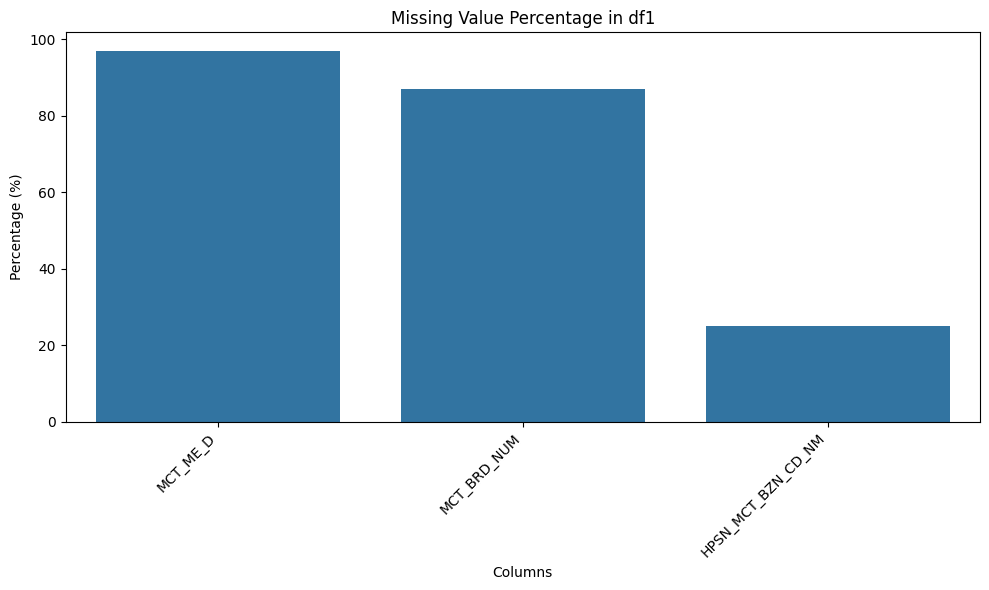

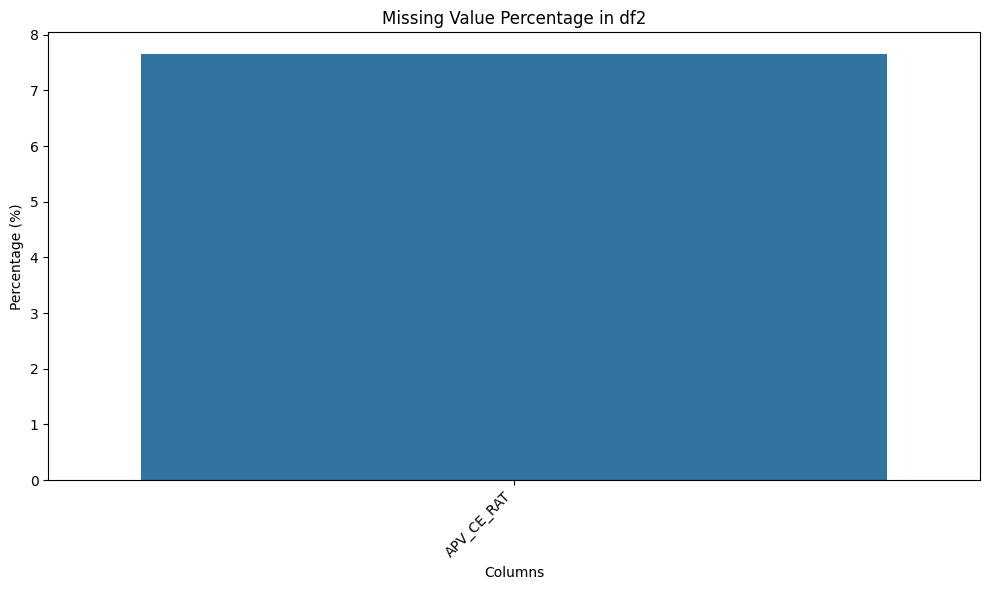

No missing values to plot for df3.


In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm

# Find available Korean fonts and set font
font_list = fm.findSystemFonts(fontpaths=None, fontext='ttf')
korean_font_list = [f for f in font_list if 'Nanum' in f or 'Malgun' in f]

if len(korean_font_list) > 0:
    # Use the first found Korean font
    plt.rcParams['font.family'] = fm.FontProperties(fname=korean_font_list[0]).get_name()
    plt.rcParams['axes.unicode_minus'] = False
    print(f"Using font: {plt.rcParams['font.family']}")
else:
    print("No Korean fonts found on the system.")
    # Fallback to a default font if no Korean font is found
    plt.rcParams['font.family'] = 'DejaVu Sans'
    plt.rcParams['axes.unicode_minus'] = True

# Plot missing values for df1
if not missing_info_df1.empty:
    plt.figure(figsize=(10, 6))
    sns.barplot(x=missing_info_df1.index, y='Missing Percentage', data=missing_info_df1)
    plt.title('Missing Value Percentage in df1')
    plt.ylabel('Percentage (%)')
    plt.xlabel('Columns')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("No missing values to plot for df1.")

# Plot missing values for df2
if not missing_info_df2.empty:
    plt.figure(figsize=(10, 6))
    sns.barplot(x=missing_info_df2.index, y='Missing Percentage', data=missing_info_df2)
    plt.title('Missing Value Percentage in df2')
    plt.ylabel('Percentage (%)')
    plt.xlabel('Columns')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("No missing values to plot for df2.")

# Plot missing values for df3
if not missing_info_df3.empty:
    plt.figure(figsize=(10, 6))
    sns.barplot(x=missing_info_df3.index, y='Missing Percentage', data=missing_info_df3)
    plt.title('Missing Value Percentage in df3')
    plt.ylabel('Percentage (%)')
    plt.xlabel('Columns')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("No missing values to plot for df3.")

## 기초 통계량

In [23]:
# Calculate and display basic statistics for numeric columns in df1
print("Basic statistics for numeric columns in df1:")
display(df1.describe())

# Calculate and display basic statistics for numeric columns in df2
print("\nBasic statistics for numeric columns in df2:")
display(df2.describe())

# Calculate and display basic statistics for numeric columns in df3
print("\nBasic statistics for numeric columns in df3:")
display(df3.describe())

Basic statistics for numeric columns in df1:


,ARE_D,MCT_ME_D
count,4.185000e+03,1.270000e+02
mean,2.018352e+07,2.024716e+07
std,5.743071e+04,6.859542e+03
min,1.990023e+07,2.023010e+07
25%,2.016032e+07,2.025017e+07
50%,2.020073e+07,2.025072e+07
75%,2.023033e+07,2.025080e+07
max,2.024122e+07,2.025082e+07



Basic statistics for numeric columns in df2:


,TA_YM,DLV_SAA_RAT,M1_SME_RY_SAA_RAT,M1_SME_RY_CNT_RAT,M12_SME_RY_SAA_PCE_RT,M12_SME_BZN_SAA_PCE_RT,M12_SME_RY_ME_MCT_RAT,M12_SME_BZN_ME_MCT_RAT
count,86590.000000,86590.000000,86590.000000,86590.000000,86590.000000,86590.000000,86590.000000,86590.000000
mean,202360.704850,-662249.470344,134.503306,152.312380,31.184643,24.070313,16.187137,-247354.685375
std,49.948354,472955.612921,167.981671,227.070665,25.253279,22.843491,3.876532,431484.515919
min,202301.000000,-999999.900000,-70.000000,0.000000,0.100000,0.000000,0.000000,-999999.900000
25%,202307.000000,-999999.900000,25.200000,22.100000,9.900000,1.300000,14.100000,4.200000
50%,202401.000000,-999999.900000,82.500000,81.700000,23.900000,18.900000,17.000000,8.000000
75%,202407.000000,3.400000,181.700000,199.600000,48.200000,39.200000,18.700000,9.000000
max,202412.000000,111.200000,4300.900000,7059.800000,100.000000,99.600000,59.100000,13.900000



Basic statistics for numeric columns in df3:


,TA_YM,M12_MAL_1020_RAT,M12_MAL_30_RAT,M12_MAL_40_RAT,M12_MAL_50_RAT,M12_MAL_60_RAT,M12_FME_1020_RAT,M12_FME_30_RAT,M12_FME_40_RAT,M12_FME_50_RAT,M12_FME_60_RAT,MCT_UE_CLN_REU_RAT,MCT_UE_CLN_NEW_RAT,RC_M1_SHC_RSD_UE_CLN_RAT,RC_M1_SHC_WP_UE_CLN_RAT,RC_M1_SHC_FLP_UE_CLN_RAT
count,86590.000000,86590.000000,86590.000000,86590.000000,86590.000000,86590.000000,86590.000000,86590.000000,86590.000000,86590.000000,86590.000000,86590.000000,86590.000000,86590.000000,86590.000000,86590.000000
mean,202360.704850,-23132.288511,-23130.483150,-23133.699739,-23132.727377,-23134.757761,-23132.931257,-23132.508397,-23135.875375,-23135.667261,-23136.852116,-18949.612306,-18964.829428,-84585.222446,-84605.088521,-84569.608085
std,49.948354,150361.910036,150362.187842,150361.692698,150361.842481,150361.530077,150361.811198,150361.876105,150361.357768,150361.389830,150361.207660,136439.003444,136436.887054,278322.440389,278316.399644,278327.187716
min,202301.000000,-999999.900000,-999999.900000,-999999.900000,-999999.900000,-999999.900000,-999999.900000,-999999.900000,-999999.900000,-999999.900000,-999999.900000,-999999.900000,-999999.900000,-999999.900000,-999999.900000,-999999.900000
25%,202307.000000,3.744925,7.509725,4.889600,4.441050,1.464000,2.272000,5.232150,4.171050,4.088000,1.358550,13.820000,4.970000,10.400000,1.100000,30.300000
50%,202401.000000,9.637500,12.284000,9.258800,8.795350,4.818600,6.802500,9.657850,6.669800,6.579150,3.369250,24.030000,6.700000,28.100000,7.600000,48.000000
75%,202407.000000,15.903450,17.985750,13.299000,14.926850,12.045925,15.247550,15.748650,9.725000,10.098000,7.451300,33.750000,8.780000,50.000000,17.100000,66.300000
max,202412.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000


## 이상치 확인

In [24]:
# # Get the list of numeric columns for each dataframe
# df1_numeric_columns = df1.select_dtypes(include=['int64', 'float64']).columns.tolist()
# df2_numeric_columns = df2.select_dtypes(include=['int64', 'float64']).columns.tolist()
# df3_numeric_columns = df3.select_dtypes(include=['int64', 'float64']).columns.tolist()

# # Function to create box plots for numeric columns, handling placeholder values
# def plot_numeric_boxplot(df, numeric_cols, df_name):
#     # Replace placeholder value with NaN for plotting purposes
#     df_cleaned = df.replace(-999999.9, np.nan)

#     n_cols = 3
#     n_rows = (len(numeric_cols) + n_cols - 1) // n_cols

#     plt.figure(figsize=(n_cols * 6, n_rows * 4))

#     for i, col in enumerate(numeric_cols):
#         plt.subplot(n_rows, n_cols, i + 1)
#         sns.boxplot(data=df_cleaned, y=col)
#         plt.title(f'{df_name} - Box Plot of {col}')
#         plt.ylabel(col)

#     plt.tight_layout()
#     plt.show()

# # Plot box plots for numeric columns in each dataframe
# print("Box plots for df1 numeric columns:")
# plot_numeric_boxplot(df1, df1_numeric_columns, 'df1')

# print("\nBox plots for df2 numeric columns:")
# plot_numeric_boxplot(df2, df2_numeric_columns, 'df2')

# print("\nBox plots for df3 numeric columns:")
# plot_numeric_boxplot(df3, df3_numeric_columns, 'df3')

## 상관 관계 분석

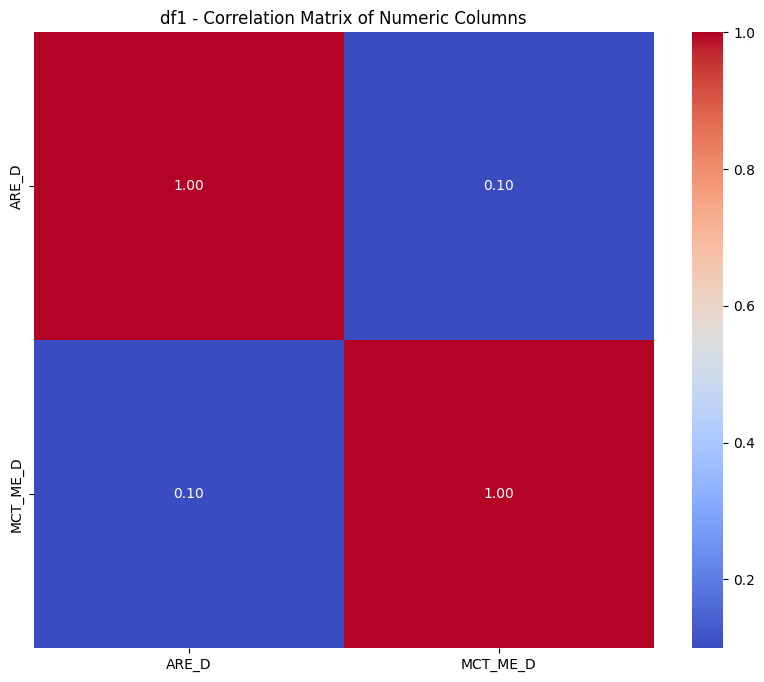

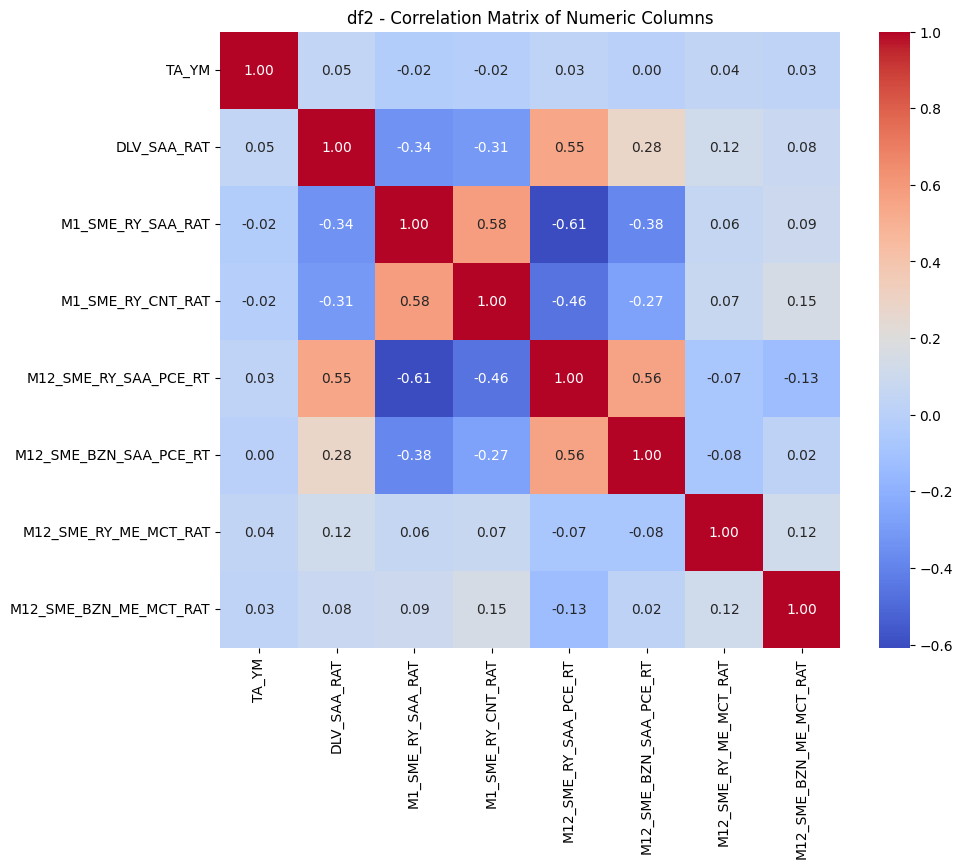

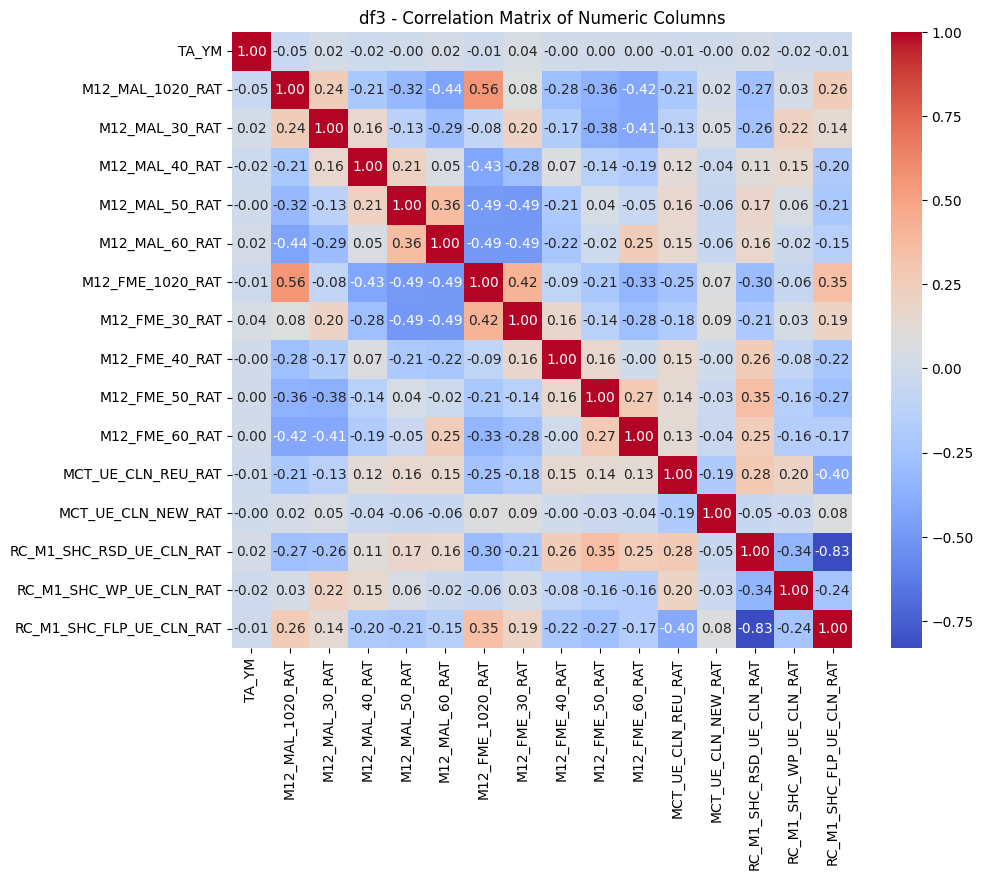

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# Function to calculate and plot correlation matrix, handling placeholder values
def plot_correlation_heatmap(df, df_name):
    # Select numeric columns
    numeric_df = df.select_dtypes(include=['int64', 'float64']).copy()

    # Replace placeholder value with NaN before calculating correlation
    numeric_df = numeric_df.replace(-999999.9, np.nan)

    # Drop columns with all NaN values after replacing placeholder
    numeric_df = numeric_df.dropna(axis=1, how='all')

    if numeric_df.shape[1] > 1:
        # Calculate the correlation matrix
        correlation_matrix = numeric_df.corr()

        # Plot the heatmap
        plt.figure(figsize=(10, 8))
        sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
        plt.title(f'{df_name} - Correlation Matrix of Numeric Columns')
        plt.show()
    else:
        print(f"DataFrame {df_name} does not have enough numeric columns (after handling placeholders) to calculate correlation.")


# Plot correlation heatmap for each dataframe
plot_correlation_heatmap(df1, 'df1')
plot_correlation_heatmap(df2, 'df2')
plot_correlation_heatmap(df3, 'df3')

# 전처리

### df1

In [26]:
# Split 'MCT_BSE_AR' into 4 columns, handling multiple spaces
df1[['MCT_BSE_AR_part1', 'MCT_BSE_AR_part2', 'MCT_BSE_AR_part3', 'MCT_BSE_AR_part4']] = df1['MCT_BSE_AR'].str.split(expand=True, n=3)

# Display the updated dataframe with the new columns
display(df1.head(20))

,ENCODED_MCT,MCT_BSE_AR,MCT_NM,MCT_BRD_NUM,MCT_SIGUNGU_NM,HPSN_MCT_ZCD_NM,HPSN_MCT_BZN_CD_NM,ARE_D,MCT_ME_D,MCT_BSE_AR_part1,MCT_BSE_AR_part2,MCT_BSE_AR_part3,MCT_BSE_AR_part4
0,16184E93D9,서울 성동구 마장동,성우**,NaN,서울 성동구,축산물,마장동,20130320,NaN,서울,성동구,마장동,None
1,4D039EA8B7,서울 성동구 마장동,대보**,NaN,서울 성동구,축산물,마장동,20131122,NaN,서울,성동구,마장동,None
2,0074C4990A,서울 성동구 마장동,대용**,NaN,서울 성동구,축산물,마장동,20140512,NaN,서울,성동구,마장동,None
3,68308F2746,서울 성동구 마장동,통일**,NaN,서울 성동구,축산물,마장동,20151124,NaN,서울,성동구,마장동,None
4,4117EDDE9C,서울 성동구 마장동,한울**,NaN,서울 성동구,축산물,마장동,20151211,NaN,서울,성동구,마장동,None
5,281CA527F1,서울 성동구 마장동,대광**,NaN,서울 성동구,축산물,마장동,20170222,NaN,서울,성동구,마장동,None
6,9A71D71270,서울 성동구 마장동,미림**,NaN,서울 성동구,식품 제조,NaN,20170817,NaN,서울,성동구,마장동,None
7,761947ABD9,서울 성동구 마장동,호남*,NaN,서울 성동구,한식-육류/고기,마장동,20130531,NaN,서울,성동구,마장동,None
8,145BA84596,서울 성동구 사근동,고향***,NaN,서울 성동구,한식-찌개/전골,한양대,20140618,NaN,서울,성동구,사근동,None
9,27C88660A5,서울 성동구 송정동,북*,NaN,서울 성동구,중식당,NaN,20141217,NaN,서울,성동구,송정동,None


In [27]:
display(df1.head(20))

,ENCODED_MCT,MCT_BSE_AR,MCT_NM,MCT_BRD_NUM,MCT_SIGUNGU_NM,HPSN_MCT_ZCD_NM,HPSN_MCT_BZN_CD_NM,ARE_D,MCT_ME_D,MCT_BSE_AR_part1,MCT_BSE_AR_part2,MCT_BSE_AR_part3,MCT_BSE_AR_part4
0,16184E93D9,서울 성동구 마장동,성우**,NaN,서울 성동구,축산물,마장동,20130320,NaN,서울,성동구,마장동,None
1,4D039EA8B7,서울 성동구 마장동,대보**,NaN,서울 성동구,축산물,마장동,20131122,NaN,서울,성동구,마장동,None
2,0074C4990A,서울 성동구 마장동,대용**,NaN,서울 성동구,축산물,마장동,20140512,NaN,서울,성동구,마장동,None
3,68308F2746,서울 성동구 마장동,통일**,NaN,서울 성동구,축산물,마장동,20151124,NaN,서울,성동구,마장동,None
4,4117EDDE9C,서울 성동구 마장동,한울**,NaN,서울 성동구,축산물,마장동,20151211,NaN,서울,성동구,마장동,None
5,281CA527F1,서울 성동구 마장동,대광**,NaN,서울 성동구,축산물,마장동,20170222,NaN,서울,성동구,마장동,None
6,9A71D71270,서울 성동구 마장동,미림**,NaN,서울 성동구,식품 제조,NaN,20170817,NaN,서울,성동구,마장동,None
7,761947ABD9,서울 성동구 마장동,호남*,NaN,서울 성동구,한식-육류/고기,마장동,20130531,NaN,서울,성동구,마장동,None
8,145BA84596,서울 성동구 사근동,고향***,NaN,서울 성동구,한식-찌개/전골,한양대,20140618,NaN,서울,성동구,사근동,None
9,27C88660A5,서울 성동구 송정동,북*,NaN,서울 성동구,중식당,NaN,20141217,NaN,서울,성동구,송정동,None


In [28]:
df1['MCT_BSE_AR_part1'].value_counts()

,count
MCT_BSE_AR_part1,
서울특별시,2787
서울,1397
경기,1


In [29]:
df1['MCT_BSE_AR_part1'] = df1['MCT_BSE_AR_part1'].replace('서울특별시', '서울')

# Verify the change
display(df1['MCT_BSE_AR_part1'].value_counts())

,count
MCT_BSE_AR_part1,
서울,4184
경기,1


In [30]:
df1['MCT_BSE_AR_part2'].value_counts()

,count
MCT_BSE_AR_part2,
성동구,4183
강남구,1
동두천시,1


In [31]:
# Filter df1 to keep only rows where 'MCT_BSE_AR_part2' is '성동구'
df1_filtered = df1[df1['MCT_BSE_AR_part2'] == '성동구'].copy()

# Optionally, update the original df1 if desired
df1 = df1_filtered

# Display the value counts to verify the filtering
display(df1['MCT_BSE_AR_part2'].value_counts())

# Display the shape of the filtered dataframe to see how many rows were removed
print(f"Original df1 shape: {df1.shape}")
print(f"Filtered df1 shape: {df1_filtered.shape}")

,count
MCT_BSE_AR_part2,
성동구,4183


Original df1 shape: (4183, 13)
Filtered df1 shape: (4183, 13)


In [32]:
df1['MCT_BSE_AR_part3'].value_counts()

,count
MCT_BSE_AR_part3,
왕십리로,236
독서당로,137
마장로,134
마조로,110
성덕정길,99
...,...
용답25나길,1
독서당로57길,1
왕십리로21다길,1


In [33]:
df1['MCT_BSE_AR_part4'].value_counts()

,count
MCT_BSE_AR_part4,
410,74
17,72
11,63
6,60
8,55
...,...
8-18,1
157-31,1
363-1 (하왕십리동),1


In [34]:
# Check for values containing '.' in 'MCT_BSE_AR_part4'
contains_dot = df1['MCT_BSE_AR_part4'].astype(str).str.contains(r'\.', na=False)
print(f"Number of values containing '.': {contains_dot.sum()}")

# Display some of the values containing '.' before replacement
if contains_dot.sum() > 0:
    print("Examples of values containing '.' before replacement:")
    display(df1.loc[contains_dot, 'MCT_BSE_AR_part4'].head())

# Remove '.' from the column
df1['MCT_BSE_AR_part4'] = df1['MCT_BSE_AR_part4'].astype(str).str.replace(r'\.', '', regex=True)

# Verify the change by checking if any value still contains '.'
contains_dot_after = df1['MCT_BSE_AR_part4'].astype(str).str.contains(r'\.', na=False)
print(f"\nNumber of values containing '.' after replacement: {contains_dot_after.sum()}")

# Display some of the values after replacement to confirm
print("Examples of values after replacement:")
display(df1.loc[contains_dot, 'MCT_BSE_AR_part4'].head())

Number of values containing '.': 831
Examples of values containing '.' before replacement:


,MCT_BSE_AR_part4
91,7.
92,2.
93,2.
121,17.
122,17.



Number of values containing '.' after replacement: 0
Examples of values after replacement:


,MCT_BSE_AR_part4
91,7
92,2
93,2
121,17
122,17


In [35]:
df1 = df1.drop('MCT_BSE_AR', axis=1)

display(df1.head())

,ENCODED_MCT,MCT_NM,MCT_BRD_NUM,MCT_SIGUNGU_NM,HPSN_MCT_ZCD_NM,HPSN_MCT_BZN_CD_NM,ARE_D,MCT_ME_D,MCT_BSE_AR_part1,MCT_BSE_AR_part2,MCT_BSE_AR_part3,MCT_BSE_AR_part4
0,16184E93D9,성우**,NaN,서울 성동구,축산물,마장동,20130320,NaN,서울,성동구,마장동,None
1,4D039EA8B7,대보**,NaN,서울 성동구,축산물,마장동,20131122,NaN,서울,성동구,마장동,None
2,0074C4990A,대용**,NaN,서울 성동구,축산물,마장동,20140512,NaN,서울,성동구,마장동,None
3,68308F2746,통일**,NaN,서울 성동구,축산물,마장동,20151124,NaN,서울,성동구,마장동,None
4,4117EDDE9C,한울**,NaN,서울 성동구,축산물,마장동,20151211,NaN,서울,성동구,마장동,None


In [36]:
df1['MCT_NM'].value_counts()

,count
MCT_NM,
성수**,31
카페***,16
성수****,12
카페**,11
서울**,10
...,...
스켓******,1
하람**,1
샐러****************,1


In [37]:
df1 = df1.drop('MCT_NM', axis=1)

display(df1.head())

,ENCODED_MCT,MCT_BRD_NUM,MCT_SIGUNGU_NM,HPSN_MCT_ZCD_NM,HPSN_MCT_BZN_CD_NM,ARE_D,MCT_ME_D,MCT_BSE_AR_part1,MCT_BSE_AR_part2,MCT_BSE_AR_part3,MCT_BSE_AR_part4
0,16184E93D9,NaN,서울 성동구,축산물,마장동,20130320,NaN,서울,성동구,마장동,None
1,4D039EA8B7,NaN,서울 성동구,축산물,마장동,20131122,NaN,서울,성동구,마장동,None
2,0074C4990A,NaN,서울 성동구,축산물,마장동,20140512,NaN,서울,성동구,마장동,None
3,68308F2746,NaN,서울 성동구,축산물,마장동,20151124,NaN,서울,성동구,마장동,None
4,4117EDDE9C,NaN,서울 성동구,축산물,마장동,20151211,NaN,서울,성동구,마장동,None


In [38]:
df1['MCT_BRD_NUM'].value_counts()

,count
MCT_BRD_NUM,
커피전문점2,20
베이커리10,18
커피전문점6,14
커피전문점11,13
커피전문점4,10
...,...
치킨21,1
한식-냉면1,1
치킨19,1


In [39]:
df1['MCT_SIGUNGU_NM'].value_counts()

,count
MCT_SIGUNGU_NM,
서울 성동구,4183


In [40]:
df1 = df1.drop('MCT_SIGUNGU_NM', axis=1)

display(df1.head())

,ENCODED_MCT,MCT_BRD_NUM,HPSN_MCT_ZCD_NM,HPSN_MCT_BZN_CD_NM,ARE_D,MCT_ME_D,MCT_BSE_AR_part1,MCT_BSE_AR_part2,MCT_BSE_AR_part3,MCT_BSE_AR_part4
0,16184E93D9,NaN,축산물,마장동,20130320,NaN,서울,성동구,마장동,None
1,4D039EA8B7,NaN,축산물,마장동,20131122,NaN,서울,성동구,마장동,None
2,0074C4990A,NaN,축산물,마장동,20140512,NaN,서울,성동구,마장동,None
3,68308F2746,NaN,축산물,마장동,20151124,NaN,서울,성동구,마장동,None
4,4117EDDE9C,NaN,축산물,마장동,20151211,NaN,서울,성동구,마장동,None


In [41]:
df1['HPSN_MCT_ZCD_NM'].value_counts().head(20)

,count
HPSN_MCT_ZCD_NM,
한식-육류/고기,442
카페,357
백반/가정식,346
한식-단품요리일반,306
축산물,285
커피전문점,182
양식,176
식료품,158
베이커리,146


In [42]:
# 그룹화를 위한 매핑 정의
category_mapping = {
    '한식': ['한식-육류/고기', '백반/가정식', '한식-단품요리일반', '한식-해물/생선', '한식-국수/만두', '한식-국밥/설렁탕', '기사식당', '칼국수/만두', '한식-기타', '곰탕/설렁탕', '냉면', '추어탕', '국수', '비빔밥', '갈비/찜', '삼겹살', '샤브샤브', '족발/보쌈', '국밥', '해물찜/탕', '찌개/전골', '순대국', '감자탕', '불고기/두루치기', '쌈밥', '아구찜/탕', '칼국수', '백반', '삼계탕', '돌솥밥', '육개장/추어탕', '전/막걸리', '곱창/막창', '곰탕', '찜닭', '한식-찌개/전골', '반찬', '한정식', '한식-냉면', '한식-감자탕', '한식-죽', '한식뷔페', '한식-두부요리', '구내식당/푸드코너', '도시락', '떡/한과 제조', '떡/한과'], # '구내식당/푸드코너' 추가
    '카페/디저트': ['카페', '커피전문점', '베이커리', '아이스크림/빙수', '도넛', '와플/크로플', '케이크', '토스트', '샌드위치/토스트', '테마카페', '마카롱', '테이크아웃커피', '도너츠', '차'],
    '외국 음식': ['양식', '일식당', '중식당', '아시아음식', '패밀리레스토랑', '퓨전음식', '태국음식', '이탈리아음식', '스페인음식', '멕시코/남미음식', '인도음식', '프랑스음식', '동남아음식', '중국음식', '파스타/스파게티', '스테이크', '피자', '일식-덮밥/돈가스', '일식-우동/소바/라면', '기타세계요리', '일식-초밥/롤', '이자카야', '일식-샤브샤브', '일식-참치회', '중식-훠궈/마라탕', '중식-딤섬/중식만두', '동남아/인도음식'],
    '분식/간식': ['분식', '치킨', '호프/맥주', '요리주점', '패스트푸드', '제과점', '떡볶이', '닭강정', '핫도그', '꼬치구이', '튀김', '탕후루', '햄버거', '포장마차', '민속주점'],
    '식료품/기타': ['축산물', '식료품', '농산물', '수산물', '건강식품', '정육점', '청과', '수산시장', '반찬가게', '유제품', '기타', '식품 제조', '인삼제품', '미곡상', '주류', '주스', '건어물', '건강원', '일반 유흥주점', '와인바', '와인샵', '담배', '청과물', '룸살롱/단란주점']
}


# 매핑을 쉽게 찾을 수 있도록 역으로 변환
reverse_category_mapping = {item: key for key, values in category_mapping.items() for item in values}

# 매핑을 기반으로 새로운 컬럼 생성
df1['HPSN_MCT_ZCD_NM_CATEGORY'] = df1['HPSN_MCT_ZCD_NM'].map(reverse_category_mapping)

# 매핑되지 않은 값이 있는지 확인 (매핑에 없는 HPSN_MCT_ZCD_NM 값이 있는 경우)
unmapped_values = df1[df1['HPSN_MCT_ZCD_NM_CATEGORY'].isnull()]['HPSN_MCT_ZCD_NM'].unique()
if len(unmapped_values) > 0:
    print("경고: 다음 HPSN_MCT_ZCD_NM 값은 매핑되지 않았습니다:")
    print(unmapped_values)
else:
    print("모든 HPSN_MCT_ZCD_NM 값이 성공적으로 매핑되었습니다.")


# 새로운 카테고리 컬럼의 값 개수 확인
display(df1['HPSN_MCT_ZCD_NM_CATEGORY'].value_counts())

# 새로운 컬럼이 포함된 데이터프레임의 처음 부분 출력
display(df1[['HPSN_MCT_ZCD_NM', 'HPSN_MCT_ZCD_NM_CATEGORY']].head())

경고: 다음 HPSN_MCT_ZCD_NM 값은 매핑되지 않았습니다:
['구내식당/푸드코트']


,count
HPSN_MCT_ZCD_NM_CATEGORY,
한식,1505
카페/디저트,798
식료품/기타,730
외국 음식,615
분식/간식,533


,HPSN_MCT_ZCD_NM,HPSN_MCT_ZCD_NM_CATEGORY
0,축산물,식료품/기타
1,축산물,식료품/기타
2,축산물,식료품/기타
3,축산물,식료품/기타
4,축산물,식료품/기타


In [43]:
df1 = df1.drop('HPSN_MCT_ZCD_NM', axis=1)

display(df1.head())

,ENCODED_MCT,MCT_BRD_NUM,HPSN_MCT_BZN_CD_NM,ARE_D,MCT_ME_D,MCT_BSE_AR_part1,MCT_BSE_AR_part2,MCT_BSE_AR_part3,MCT_BSE_AR_part4,HPSN_MCT_ZCD_NM_CATEGORY
0,16184E93D9,NaN,마장동,20130320,NaN,서울,성동구,마장동,None,식료품/기타
1,4D039EA8B7,NaN,마장동,20131122,NaN,서울,성동구,마장동,None,식료품/기타
2,0074C4990A,NaN,마장동,20140512,NaN,서울,성동구,마장동,None,식료품/기타
3,68308F2746,NaN,마장동,20151124,NaN,서울,성동구,마장동,None,식료품/기타
4,4117EDDE9C,NaN,마장동,20151211,NaN,서울,성동구,마장동,None,식료품/기타


In [44]:
df1['HPSN_MCT_BZN_CD_NM'].value_counts().head(20)

,count
HPSN_MCT_BZN_CD_NM,
성수,762
왕십리,538
뚝섬,468
한양대,328
마장동,257
금남시장,249
답십리,179
옥수,121
신금호,100


In [45]:
# HPSN_MCT_BZN_CD_NM 컬럼의 값별 개수를 계산
bzn_counts = df1['HPSN_MCT_BZN_CD_NM'].value_counts()

# 값이 한 번만 나타나는 HPSN_MCT_BZN_CD_NM 값들을 식별
single_occurrence_bzns = bzn_counts[bzn_counts == 1].index

# df1에서 값이 한 번만 나타나는 HPSN_MCT_BZN_CD_NM를 포함하는 행들을 제외하고 필터링
df1_filtered = df1[~df1['HPSN_MCT_BZN_CD_NM'].isin(single_occurrence_bzns)].copy()

# 원본 df1을 필터링된 데이터프레임으로 업데이트 (원하는 경우)
df1 = df1_filtered

# 제거 후 HPSN_MCT_BZN_CD_NM 컬럼의 값 개수를 다시 확인 (상위 20개)
display(df1['HPSN_MCT_BZN_CD_NM'].value_counts().head(20))

# 필터링된 데이터프레임의 행 개수를 확인하여 몇 개의 행이 제거되었는지 확인
print(f"원본 df1 형태: {df1.shape}")
print(f"필터링된 df1 형태: {df1_filtered.shape}")

,count
HPSN_MCT_BZN_CD_NM,
성수,762
왕십리,538
뚝섬,468
한양대,328
마장동,257
금남시장,249
답십리,179
옥수,121
신금호,100


원본 df1 형태: (4173, 10)
필터링된 df1 형태: (4173, 10)


In [46]:
df1['ARE_D'].value_counts().head(20)

,count
ARE_D,
20220622,7
20221031,7
20231005,7
20240426,7
20210709,7
20240509,7
20220418,6
20230927,6
20211208,6


In [47]:
# ARE_D 컬럼을 문자열로 변환하고 datetime 형식으로 변환 (errors='coerce'를 사용하여 변환 불가능한 값은 NaT 처리)
df1['ARE_D_datetime'] = pd.to_datetime(df1['ARE_D'].astype(str), format='%Y%m%d', errors='coerce')

# datetime 컬럼에서 연, 월, 일 추출하여 새로운 컬럼 생성
df1['ARE_D_year'] = df1['ARE_D_datetime'].dt.year
df1['ARE_D_month'] = df1['ARE_D_datetime'].dt.month
df1['ARE_D_day'] = df1['ARE_D_datetime'].dt.day

# 원래 ARE_D 컬럼과 새로 생성된 컬럼들을 함께 출력하여 확인
display(df1[['ARE_D', 'ARE_D_year', 'ARE_D_month', 'ARE_D_day', 'ARE_D_datetime']].head())

# 변환 중 발생한 NaT 값 (원래 ARE_D 값 중 유효하지 않은 날짜 형식)이 있는지 확인
if df1['ARE_D_datetime'].isnull().sum() > 0:
    print(f"경고: ARE_D 컬럼 변환 중 {df1['ARE_D_datetime'].isnull().sum()}개의 유효하지 않은 날짜 형식이 발견되어 NaT로 처리되었습니다.")

,ARE_D,ARE_D_year,ARE_D_month,ARE_D_day,ARE_D_datetime
0,20130320,2013,3,20,2013-03-20
1,20131122,2013,11,22,2013-11-22
2,20140512,2014,5,12,2014-05-12
3,20151124,2015,11,24,2015-11-24
4,20151211,2015,12,11,2015-12-11


In [48]:
df1 = df1.drop('ARE_D', axis=1)
df1 = df1.drop('ARE_D_datetime', axis=1)

display(df1.head())

,ENCODED_MCT,MCT_BRD_NUM,HPSN_MCT_BZN_CD_NM,MCT_ME_D,MCT_BSE_AR_part1,MCT_BSE_AR_part2,MCT_BSE_AR_part3,MCT_BSE_AR_part4,HPSN_MCT_ZCD_NM_CATEGORY,ARE_D_year,ARE_D_month,ARE_D_day
0,16184E93D9,NaN,마장동,NaN,서울,성동구,마장동,None,식료품/기타,2013,3,20
1,4D039EA8B7,NaN,마장동,NaN,서울,성동구,마장동,None,식료품/기타,2013,11,22
2,0074C4990A,NaN,마장동,NaN,서울,성동구,마장동,None,식료품/기타,2014,5,12
3,68308F2746,NaN,마장동,NaN,서울,성동구,마장동,None,식료품/기타,2015,11,24
4,4117EDDE9C,NaN,마장동,NaN,서울,성동구,마장동,None,식료품/기타,2015,12,11


In [49]:
df1['MCT_ME_D'].value_counts().head(30)

,count
MCT_ME_D,
20250811.0,7
20250730.0,6
20250801.0,5
20250731.0,4
20250728.0,4
20250721.0,4
20250814.0,4
20250714.0,4
20250808.0,3


In [50]:
# 'MCT_ME_D' 컬럼의 결측 여부를 확인하여 '폐업여부' 컬럼 생성
# 결측이 아니면(값이 존재하면) 1 (폐업), 결측이면 0 (영업 중)
df1['MCT_ME_CLOSED'] = df1['MCT_ME_D'].notnull().astype(int)

# 새로 생성된 '폐업여부' 컬럼의 값 개수를 확인
display(df1['MCT_ME_CLOSED'].value_counts())

# 데이터프레임의 처음 부분을 출력하여 '폐업여부' 컬럼 확인
display(df1.head())

,count
MCT_ME_CLOSED,
0,4046
1,127


,ENCODED_MCT,MCT_BRD_NUM,HPSN_MCT_BZN_CD_NM,MCT_ME_D,MCT_BSE_AR_part1,MCT_BSE_AR_part2,MCT_BSE_AR_part3,MCT_BSE_AR_part4,HPSN_MCT_ZCD_NM_CATEGORY,ARE_D_year,ARE_D_month,ARE_D_day,MCT_ME_CLOSED
0,16184E93D9,NaN,마장동,NaN,서울,성동구,마장동,None,식료품/기타,2013,3,20,0
1,4D039EA8B7,NaN,마장동,NaN,서울,성동구,마장동,None,식료품/기타,2013,11,22,0
2,0074C4990A,NaN,마장동,NaN,서울,성동구,마장동,None,식료품/기타,2014,5,12,0
3,68308F2746,NaN,마장동,NaN,서울,성동구,마장동,None,식료품/기타,2015,11,24,0
4,4117EDDE9C,NaN,마장동,NaN,서울,성동구,마장동,None,식료품/기타,2015,12,11,0


In [51]:
df1 = df1.drop('MCT_ME_D', axis=1)

display(df1.head())

,ENCODED_MCT,MCT_BRD_NUM,HPSN_MCT_BZN_CD_NM,MCT_BSE_AR_part1,MCT_BSE_AR_part2,MCT_BSE_AR_part3,MCT_BSE_AR_part4,HPSN_MCT_ZCD_NM_CATEGORY,ARE_D_year,ARE_D_month,ARE_D_day,MCT_ME_CLOSED
0,16184E93D9,NaN,마장동,서울,성동구,마장동,None,식료품/기타,2013,3,20,0
1,4D039EA8B7,NaN,마장동,서울,성동구,마장동,None,식료품/기타,2013,11,22,0
2,0074C4990A,NaN,마장동,서울,성동구,마장동,None,식료품/기타,2014,5,12,0
3,68308F2746,NaN,마장동,서울,성동구,마장동,None,식료품/기타,2015,11,24,0
4,4117EDDE9C,NaN,마장동,서울,성동구,마장동,None,식료품/기타,2015,12,11,0


In [52]:
display(df1.head())

,ENCODED_MCT,MCT_BRD_NUM,HPSN_MCT_BZN_CD_NM,MCT_BSE_AR_part1,MCT_BSE_AR_part2,MCT_BSE_AR_part3,MCT_BSE_AR_part4,HPSN_MCT_ZCD_NM_CATEGORY,ARE_D_year,ARE_D_month,ARE_D_day,MCT_ME_CLOSED
0,16184E93D9,NaN,마장동,서울,성동구,마장동,None,식료품/기타,2013,3,20,0
1,4D039EA8B7,NaN,마장동,서울,성동구,마장동,None,식료품/기타,2013,11,22,0
2,0074C4990A,NaN,마장동,서울,성동구,마장동,None,식료품/기타,2014,5,12,0
3,68308F2746,NaN,마장동,서울,성동구,마장동,None,식료품/기타,2015,11,24,0
4,4117EDDE9C,NaN,마장동,서울,성동구,마장동,None,식료품/기타,2015,12,11,0


In [53]:
# df1 데이터프레임의 각 컬럼별 결측치 개수 계산
missing_values_df1 = df1.isnull().sum()

# 결측치가 있는 컬럼만 필터링하여 출력 (모든 컬럼을 보려면 필터링 제거)
print("df1 컬럼별 결측치 개수:")
display(missing_values_df1[missing_values_df1 > 0])

df1 컬럼별 결측치 개수:


,0
MCT_BRD_NUM,3632
HPSN_MCT_BZN_CD_NM,1046
HPSN_MCT_ZCD_NM_CATEGORY,2


HPSN_MCT_ZCD_NM_CATEGORY 별 MCT_BRD_NUM 결측 비율:


,MCT_BRD_NUM_isnull
HPSN_MCT_ZCD_NM_CATEGORY,
식료품/기타,0.965659
외국 음식,0.918301
한식,0.902130
카페/디저트,0.789210
분식/간식,0.716165


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Using font: ['NanumGothic']


/tmp/ipython-input-1040814162.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_rate_by_category.index, y=missing_rate_by_category.values, palette='viridis')


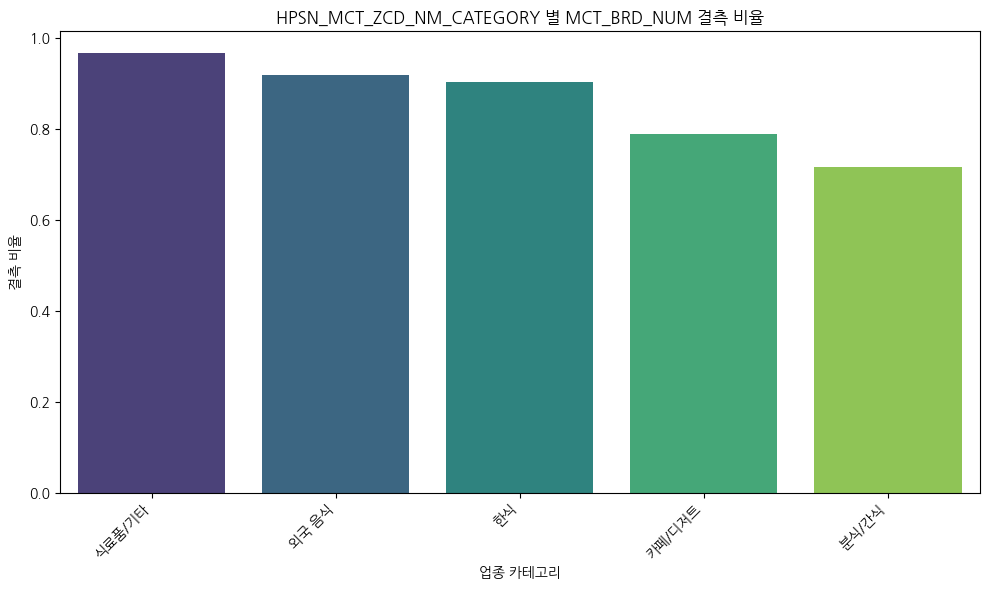

In [54]:
# HPSN_MCT_ZCD_NM_CATEGORY 별 MCT_BRD_NUM의 결측 여부 확인
# True는 결측, False는 값 존재
df1['MCT_BRD_NUM_isnull'] = df1['MCT_BRD_NUM'].isnull()

# HPSN_MCT_ZCD_NM_CATEGORY 별 MCT_BRD_NUM 결측 비율 계산
missing_rate_by_category = df1.groupby('HPSN_MCT_ZCD_NM_CATEGORY')['MCT_BRD_NUM_isnull'].mean().sort_values(ascending=False)

# 결과 출력
print("HPSN_MCT_ZCD_NM_CATEGORY 별 MCT_BRD_NUM 결측 비율:")
display(missing_rate_by_category)

# 결측 여부 임시 컬럼 제거
df1 = df1.drop('MCT_BRD_NUM_isnull', axis=1)

# 결측 비율 시각화
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm

# 나눔고딕 폰트 설치 (코랩 환경)
!apt-get update -qq
!apt-get install fonts-nanum -qq > /dev/null

# 설치된 폰트 캐시 재설정
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')

# 한글 폰트 설정
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False
print(f"Using font: {plt.rcParams['font.family']}")


plt.figure(figsize=(10, 6))
sns.barplot(x=missing_rate_by_category.index, y=missing_rate_by_category.values, palette='viridis')
plt.title('HPSN_MCT_ZCD_NM_CATEGORY 별 MCT_BRD_NUM 결측 비율')
plt.ylabel('결측 비율')
plt.xlabel('업종 카테고리')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [55]:
# # MCT_BRD_NUM 컬럼의 결측치(NaN)를 문자열 'None'으로 채우기
# df1['MCT_BRD_NUM'] = df1['MCT_BRD_NUM'].fillna('None')

# # 변경 확인을 위해 결측치 개수 다시 확인
# print("MCT_BRD_NUM 컬럼의 결측치 개수 (None으로 채운 후):")
# display(df1['MCT_BRD_NUM'].isnull().sum())

# # 변경된 데이터프레임의 처음 부분 확인
# display(df1.head())

In [56]:
df1['HPSN_MCT_BZN_CD_NM'].value_counts().head(20)

,count
HPSN_MCT_BZN_CD_NM,
성수,762
왕십리,538
뚝섬,468
한양대,328
마장동,257
금남시장,249
답십리,179
옥수,121
신금호,100


In [57]:
# # HPSN_MCT_BZN_CD_NM 컬럼의 결측치(NaN)를 문자열 'None'으로 채우기
# df1['HPSN_MCT_BZN_CD_NM'] = df1['HPSN_MCT_BZN_CD_NM'].fillna('None')

# # 변경 확인을 위해 결측치 개수 다시 확인
# print("HPSN_MCT_BZN_CD_NM 컬럼의 결측치 개수 (None으로 채운 후):")
# display(df1['HPSN_MCT_BZN_CD_NM'].isnull().sum())

# # 변경된 데이터프레임의 처음 부분 확인
# display(df1.head())

In [58]:
display(df1.head())

,ENCODED_MCT,MCT_BRD_NUM,HPSN_MCT_BZN_CD_NM,MCT_BSE_AR_part1,MCT_BSE_AR_part2,MCT_BSE_AR_part3,MCT_BSE_AR_part4,HPSN_MCT_ZCD_NM_CATEGORY,ARE_D_year,ARE_D_month,ARE_D_day,MCT_ME_CLOSED
0,16184E93D9,NaN,마장동,서울,성동구,마장동,None,식료품/기타,2013,3,20,0
1,4D039EA8B7,NaN,마장동,서울,성동구,마장동,None,식료품/기타,2013,11,22,0
2,0074C4990A,NaN,마장동,서울,성동구,마장동,None,식료품/기타,2014,5,12,0
3,68308F2746,NaN,마장동,서울,성동구,마장동,None,식료품/기타,2015,11,24,0
4,4117EDDE9C,NaN,마장동,서울,성동구,마장동,None,식료품/기타,2015,12,11,0


In [59]:
# Filter rows where 'HPSN_MCT_ZCD_NM_CATEGORY' is null
missing_category_rows = df1[df1['HPSN_MCT_ZCD_NM_CATEGORY'].isnull()]

# Display the relevant columns for these rows
# Displaying all columns might be too wide, so let's select a few informative ones
display(missing_category_rows[['ENCODED_MCT', 'MCT_BRD_NUM', 'HPSN_MCT_BZN_CD_NM', 'HPSN_MCT_ZCD_NM_CATEGORY', 'ARE_D_year', 'ARE_D_month', 'ARE_D_day', 'MCT_ME_CLOSED']])

,ENCODED_MCT,MCT_BRD_NUM,HPSN_MCT_BZN_CD_NM,HPSN_MCT_ZCD_NM_CATEGORY,ARE_D_year,ARE_D_month,ARE_D_day,MCT_ME_CLOSED
1932,C8BFE622A5,NaN,성수,NaN,2023,9,27,1
2165,56CE6776C6,NaN,왕십리,NaN,2022,9,20,0


In [60]:
# HPSN_MCT_ZCD_NM_CATEGORY 컬럼에 결측치가 없는 행만 남기고 필터링
df1_filtered = df1.dropna(subset=['HPSN_MCT_ZCD_NM_CATEGORY']).copy()

# 원본 df1을 필터링된 데이터프레임으로 업데이트
df1 = df1_filtered

# 변경 후 HPSN_MCT_ZCD_NM_CATEGORY 결측치 개수 확인
print(f"HPSN_MCT_ZCD_NM_CATEGORY 결측치 개수 (삭제 후): {df1['HPSN_MCT_ZCD_NM_CATEGORY'].isnull().sum()}")

# 필터링된 데이터프레임의 행 개수를 확인하여 몇 개의 행이 제거되었는지 확인
print(f"원본 df1 형태: {df1.shape}")
print(f"필터링된 df1 형태: {df1_filtered.shape}")

HPSN_MCT_ZCD_NM_CATEGORY 결측치 개수 (삭제 후): 0
원본 df1 형태: (4171, 12)
필터링된 df1 형태: (4171, 12)


### df2

In [61]:
df2.head()

,ENCODED_MCT,TA_YM,MCT_OPE_MS_CN,RC_M1_SAA,RC_M1_TO_UE_CT,RC_M1_UE_CUS_CN,RC_M1_AV_NP_AT,APV_CE_RAT,DLV_SAA_RAT,M1_SME_RY_SAA_RAT,M1_SME_RY_CNT_RAT,M12_SME_RY_SAA_PCE_RT,M12_SME_BZN_SAA_PCE_RT,M12_SME_RY_ME_MCT_RAT,M12_SME_BZN_ME_MCT_RAT
0,000F03E44A,202404,4_50-75%,5_75-90%,5_75-90%,5_75-90%,5_75-90%,1_상위1구간,-999999.9,2.6,10.6,93.8,71.5,16.7,7.8
1,000F03E44A,202312,4_50-75%,6_90%초과(하위 10% 이하),6_90%초과(하위 10% 이하),6_90%초과(하위 10% 이하),6_90%초과(하위 10% 이하),NaN,-999999.9,0.0,0.0,94.8,73.4,16.6,7.2
2,002816BA73,202404,2_10-25%,3_25-50%,4_50-75%,4_50-75%,2_10-25%,6_상위6구간(하위1구간),-999999.9,96.6,40.8,15.6,20.0,17.5,5.2
3,002816BA73,202411,2_10-25%,3_25-50%,4_50-75%,4_50-75%,2_10-25%,6_상위6구간(하위1구간),-999999.9,108.0,46.4,16.8,19.8,16.9,6.9
4,002816BA73,202406,2_10-25%,4_50-75%,4_50-75%,4_50-75%,2_10-25%,1_상위1구간,-999999.9,74.2,38.1,16.0,19.9,17.3,5.6


In [62]:
# 각 컬럼의 고유값 확인
print("MCT_OPE_MS_CN 고유값:")
display(df2['MCT_OPE_MS_CN'].value_counts().sort_index())

print("\nRC_M1_SAA 고유값:")
display(df2['RC_M1_SAA'].value_counts().sort_index())

print("\nRC_M1_TO_UE_CT 고유값:")
display(df2['RC_M1_TO_UE_CT'].value_counts().sort_index())

print("\nRC_M1_UE_CUS_CN 고유값:")
display(df2['RC_M1_UE_CUS_CN'].value_counts().sort_index())

print("\nRC_M1_AV_NP_AT 고유값:")
display(df2['RC_M1_AV_NP_AT'].value_counts().sort_index())

print("\nAPV_CE_RAT 고유값:")
display(df2['APV_CE_RAT'].value_counts().sort_index())

MCT_OPE_MS_CN 고유값:


,count
MCT_OPE_MS_CN,
1_10%이하,8691
2_10-25%,13119
3_25-50%,21812
4_50-75%,21567
5_75-90%,13454
6_90%초과(하위 10% 이하),7947



RC_M1_SAA 고유값:


,count
RC_M1_SAA,
1_10%이하,8799
2_10-25%,13167
3_25-50%,21800
4_50-75%,21692
5_75-90%,12912
6_90%초과(하위 10% 이하),8220



RC_M1_TO_UE_CT 고유값:


...

,count
RC_M1_UE_CUS_CN,
1_10%이하,8771
2_10-25%,13147
3_25-50%,21934
4_50-75%,22026
5_75-90%,14001
6_90%초과(하위 10% 이하),6711



RC_M1_AV_NP_AT 고유값:


,count
RC_M1_AV_NP_AT,
1_10%이하,8690
2_10-25%,13143
3_25-50%,21918
4_50-75%,21781
5_75-90%,12888
6_90%초과(하위 10% 이하),8170



APV_CE_RAT 고유값:


,count
APV_CE_RAT,
1_상위1구간,52445
2_상위2구간,4994
3_상위3구간,5457
4_상위4구간,5551
5_상위5구간,5697
6_상위6구간(하위1구간),5814


In [63]:
# 순서형 범주형 컬럼들에 대한 매핑 정의 (숫자가 작을수록 좋은 의미이므로, 숫자가 클수록 좋은 의미가 되도록 역매핑)
# 예: 1_10%이하 -> 6, 6_90%초과(하위 10% 이하) -> 1
mapping = {
    '1_10%이하': 6,
    '2_10-25%': 5,
    '3_25-50%': 4,
    '4_50-75%': 3,
    '5_75-90%': 2,
    '6_90%초과(하위 10% 이하)': 1
}

# APV_CE_RAT 컬럼에 대한 매핑 정의 (상위 구간일수록 좋은 의미이므로, 숫자가 클수록 좋은 의미가 되도록 역매핑)
# 예: 1_상위1구간 -> 6, 6_상위6구간(하위1구간) -> 1
apv_mapping = {
    '1_상위1구간': 6,
    '2_상위2구간': 5,
    '3_상위3구간': 4,
    '4_상위4구간': 3,
    '5_상위5구간': 2,
    '6_상위6구간(하위1구간)': 1
}


# 매핑을 적용할 컬럼 목록
columns_to_map = ['MCT_OPE_MS_CN', 'RC_M1_SAA', 'RC_M1_TO_UE_CT', 'RC_M1_UE_CUS_CN', 'RC_M1_AV_NP_AT']

# 지정된 컬럼들에 매핑 적용
for col in columns_to_map:
    df2[col + '_mapped'] = df2[col].replace(mapping)

# APV_CE_RAT 컬럼에 매핑 적용
df2['APV_CE_RAT_mapped'] = df2['APV_CE_RAT'].replace(apv_mapping)


# 변환된 컬럼들과 원본 컬럼 일부를 함께 출력하여 확인
display(df2[['MCT_OPE_MS_CN', 'MCT_OPE_MS_CN_mapped',
             'RC_M1_SAA', 'RC_M1_SAA_mapped',
             'APV_CE_RAT', 'APV_CE_RAT_mapped']].head())

# 변환된 컬럼들의 데이터 타입 확인
print("\n변환된 컬럼들의 데이터 타입:")
print(df2[['MCT_OPE_MS_CN_mapped', 'RC_M1_SAA_mapped', 'APV_CE_RAT_mapped']].dtypes)

/tmp/ipython-input-99909987.py:29: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df2[col + '_mapped'] = df2[col].replace(mapping)
/tmp/ipython-input-99909987.py:29: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df2[col + '_mapped'] = df2[col].replace(mapping)
/tmp/ipython-input-99909987.py:29: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('fut

,MCT_OPE_MS_CN,MCT_OPE_MS_CN_mapped,RC_M1_SAA,RC_M1_SAA_mapped,APV_CE_RAT,APV_CE_RAT_mapped
0,4_50-75%,3,5_75-90%,2,1_상위1구간,6.0
1,4_50-75%,3,6_90%초과(하위 10% 이하),1,NaN,NaN
2,2_10-25%,5,3_25-50%,4,6_상위6구간(하위1구간),1.0
3,2_10-25%,5,3_25-50%,4,6_상위6구간(하위1구간),1.0
4,2_10-25%,5,4_50-75%,3,1_상위1구간,6.0



변환된 컬럼들의 데이터 타입:
MCT_OPE_MS_CN_mapped      int64
RC_M1_SAA_mapped          int64
APV_CE_RAT_mapped       float64
dtype: object


In [64]:
# 삭제할 컬럼 목록
columns_to_drop_df2 = ['MCT_OPE_MS_CN', 'RC_M1_SAA', 'RC_M1_TO_UE_CT', 'RC_M1_UE_CUS_CN', 'RC_M1_AV_NP_AT', 'APV_CE_RAT']

# df2에서 지정된 컬럼 삭제
df2 = df2.drop(columns=columns_to_drop_df2)

# 변경된 데이터프레임의 처음 부분을 출력하여 확인
display(df2.head())

,ENCODED_MCT,TA_YM,DLV_SAA_RAT,M1_SME_RY_SAA_RAT,M1_SME_RY_CNT_RAT,M12_SME_RY_SAA_PCE_RT,M12_SME_BZN_SAA_PCE_RT,M12_SME_RY_ME_MCT_RAT,M12_SME_BZN_ME_MCT_RAT,MCT_OPE_MS_CN_mapped,RC_M1_SAA_mapped,RC_M1_TO_UE_CT_mapped,RC_M1_UE_CUS_CN_mapped,RC_M1_AV_NP_AT_mapped,APV_CE_RAT_mapped
0,000F03E44A,202404,-999999.9,2.6,10.6,93.8,71.5,16.7,7.8,3,2,2,2,2,6.0
1,000F03E44A,202312,-999999.9,0.0,0.0,94.8,73.4,16.6,7.2,3,1,1,1,1,NaN
2,002816BA73,202404,-999999.9,96.6,40.8,15.6,20.0,17.5,5.2,5,4,3,3,5,1.0
3,002816BA73,202411,-999999.9,108.0,46.4,16.8,19.8,16.9,6.9,5,4,3,3,5,1.0
4,002816BA73,202406,-999999.9,74.2,38.1,16.0,19.9,17.3,5.6,5,3,3,3,5,6.0


In [65]:
# Replace -999999.9 with 0 in the specified columns
df2['DLV_SAA_RAT'] = df2['DLV_SAA_RAT'].replace(-999999.9, 0)
df2['M12_SME_BZN_ME_MCT_RAT'] = df2['M12_SME_BZN_ME_MCT_RAT'].replace(-999999.9, 0)

# Verify the change by checking the minimum value and value counts of -999999.9
print("DLV_SAA_RAT 컬럼의 최소값 (변경 후):")
display(df2['DLV_SAA_RAT'].min())

print("\nM12_SME_BZN_ME_MCT_RAT 컬럼의 최소값 (변경 후):")
display(df2['M12_SME_BZN_ME_MCT_RAT'].min()) # Corrected column name

print("\nDLV_SAA_RAT 컬럼에서 -999999.9 값 개수 (변경 후):")
display(df2[df2['DLV_SAA_RAT'] == -999999.9].shape[0])

print("\nM12_SME_BZN_ME_MCT_RAT 컬럼에서 -999999.9 값 개수 (변경 후):")
display(df2[df2['M12_SME_BZN_ME_MCT_RAT'] == -999999.9].shape[0])

# 데이터프레임의 처음 부분을 출력하여 변경 확인
display(df2.head())

DLV_SAA_RAT 컬럼의 최소값 (변경 후):


0.0


M12_SME_BZN_ME_MCT_RAT 컬럼의 최소값 (변경 후):


0.0


DLV_SAA_RAT 컬럼에서 -999999.9 값 개수 (변경 후):


0


M12_SME_BZN_ME_MCT_RAT 컬럼에서 -999999.9 값 개수 (변경 후):


0

,ENCODED_MCT,TA_YM,DLV_SAA_RAT,M1_SME_RY_SAA_RAT,M1_SME_RY_CNT_RAT,M12_SME_RY_SAA_PCE_RT,M12_SME_BZN_SAA_PCE_RT,M12_SME_RY_ME_MCT_RAT,M12_SME_BZN_ME_MCT_RAT,MCT_OPE_MS_CN_mapped,RC_M1_SAA_mapped,RC_M1_TO_UE_CT_mapped,RC_M1_UE_CUS_CN_mapped,RC_M1_AV_NP_AT_mapped,APV_CE_RAT_mapped
0,000F03E44A,202404,0.0,2.6,10.6,93.8,71.5,16.7,7.8,3,2,2,2,2,6.0
1,000F03E44A,202312,0.0,0.0,0.0,94.8,73.4,16.6,7.2,3,1,1,1,1,NaN
2,002816BA73,202404,0.0,96.6,40.8,15.6,20.0,17.5,5.2,5,4,3,3,5,1.0
3,002816BA73,202411,0.0,108.0,46.4,16.8,19.8,16.9,6.9,5,4,3,3,5,1.0
4,002816BA73,202406,0.0,74.2,38.1,16.0,19.9,17.3,5.6,5,3,3,3,5,6.0


### df3

In [66]:
df3.head(20)

,ENCODED_MCT,TA_YM,M12_MAL_1020_RAT,M12_MAL_30_RAT,M12_MAL_40_RAT,M12_MAL_50_RAT,M12_MAL_60_RAT,M12_FME_1020_RAT,M12_FME_30_RAT,M12_FME_40_RAT,M12_FME_50_RAT,M12_FME_60_RAT,MCT_UE_CLN_REU_RAT,MCT_UE_CLN_NEW_RAT,RC_M1_SHC_RSD_UE_CLN_RAT,RC_M1_SHC_WP_UE_CLN_RAT,RC_M1_SHC_FLP_UE_CLN_RAT
0,0305234DDB,202311,0.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100.00,0.00,-999999.9,-999999.9,-999999.9
1,0495B069FF,202403,0.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,25.00,25.00,0.0,0.0,100.0
2,0495B069FF,202405,0.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,33.33,0.00,-999999.9,-999999.9,-999999.9
3,0495B069FF,202406,0.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,33.33,0.00,-999999.9,-999999.9,-999999.9
4,055EDDDD01,202410,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100.0,0.0,33.33,0.00,-999999.9,-999999.9,-999999.9
5,055EDDDD01,202311,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,50.0,50.0,33.33,0.00,-999999.9,-999999.9,-999999.9
6,06A87DAA45,202411,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100.0,100.00,0.00,0.0,100.0,0.0
7,06A87DAA45,202310,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100.0,100.00,0.00,-999999.9,-999999.9,-999999.9
8,06A87DAA45,202312,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100.0,100.00,0.00,-999999.9,-999999.9,-999999.9
9,09D2771DD5,202406,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100.0,0.0,0.00,0.00,-999999.9,-999999.9,-999999.9


In [67]:
# Replace -999999.9 with 0 in all columns of df3
df3 = df3.replace(-999999.9, 0)

# Verify the change by checking the minimum values in numeric columns
print("df3 수치형 컬럼들의 최소값 (변경 후):")
display(df3.select_dtypes(include=np.number).min())

# Check if -999999.9 still exists in any column
print("\ndf3에서 -999999.9 값이 존재하는 컬럼 (변경 후):")
cols_with_placeholder = [(col, (df3[col] == -999999.9).sum()) for col in df3.columns if (df3[col] == -999999.9).sum() > 0]
if cols_with_placeholder:
    display(cols_with_placeholder)
else:
    print("모든 -999999.9 값이 성공적으로 대체되었습니다.")


# 데이터프레임의 처음 부분을 출력하여 변경 확인
display(df3.head())

df3 수치형 컬럼들의 최소값 (변경 후):


,0
TA_YM,202301.0
M12_MAL_1020_RAT,0.0
M12_MAL_30_RAT,0.0
M12_MAL_40_RAT,0.0
M12_MAL_50_RAT,0.0
M12_MAL_60_RAT,0.0
M12_FME_1020_RAT,0.0
M12_FME_30_RAT,0.0
M12_FME_40_RAT,0.0
M12_FME_50_RAT,0.0



df3에서 -999999.9 값이 존재하는 컬럼 (변경 후):
모든 -999999.9 값이 성공적으로 대체되었습니다.


,ENCODED_MCT,TA_YM,M12_MAL_1020_RAT,M12_MAL_30_RAT,M12_MAL_40_RAT,M12_MAL_50_RAT,M12_MAL_60_RAT,M12_FME_1020_RAT,M12_FME_30_RAT,M12_FME_40_RAT,M12_FME_50_RAT,M12_FME_60_RAT,MCT_UE_CLN_REU_RAT,MCT_UE_CLN_NEW_RAT,RC_M1_SHC_RSD_UE_CLN_RAT,RC_M1_SHC_WP_UE_CLN_RAT,RC_M1_SHC_FLP_UE_CLN_RAT
0,0305234DDB,202311,0.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100.00,0.0,0.0,0.0,0.0
1,0495B069FF,202403,0.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,25.00,25.0,0.0,0.0,100.0
2,0495B069FF,202405,0.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,33.33,0.0,0.0,0.0,0.0
3,0495B069FF,202406,0.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,33.33,0.0,0.0,0.0,0.0
4,055EDDDD01,202410,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100.0,0.0,33.33,0.0,0.0,0.0,0.0


In [68]:
# df3 데이터프레임의 각 컬럼별 결측치 개수 계산
missing_values_df3 = df3.isnull().sum()

# 결측치가 있는 컬럼만 필터링하여 출력
print("df3 컬럼별 결측치 개수:")
display(missing_values_df3[missing_values_df3 > 0])

df3 컬럼별 결측치 개수:


,0


### 통합 및 추가 전처리

In [69]:
# df2와 df3를 'ENCODED_MCT'와 'TA_YM' 기준으로 내부 조인 (inner join)
# 두 데이터프레임에 모두 존재하는 가맹점과 월의 데이터만 남깁니다.
merged_df = pd.merge(df2, df3, on=['ENCODED_MCT', 'TA_YM'], how='inner')

# df1과 이전 결과를 'ENCODED_MCT' 기준으로 내부 조인
# df1에 존재하는 가맹점의 데이터만 남깁니다.
final_df = pd.merge(merged_df, df1, on='ENCODED_MCT', how='inner')

# 결합된 데이터프레임의 정보와 처음 부분을 출력하여 확인
print("결합된 데이터프레임 정보:")
display(final_df.info())

print("\n결합된 데이터프레임 처음 5행:")
display(final_df.head())

결합된 데이터프레임 정보:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 86295 entries, 0 to 86294
Data columns (total 41 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ENCODED_MCT               86295 non-null  object 
 1   TA_YM                     86295 non-null  int64  
 2   DLV_SAA_RAT               86295 non-null  float64
 3   M1_SME_RY_SAA_RAT         86295 non-null  float64
 4   M1_SME_RY_CNT_RAT         86295 non-null  float64
 5   M12_SME_RY_SAA_PCE_RT     86295 non-null  float64
 6   M12_SME_BZN_SAA_PCE_RT    86295 non-null  float64
 7   M12_SME_RY_ME_MCT_RAT     86295 non-null  float64
 8   M12_SME_BZN_ME_MCT_RAT    86295 non-null  float64
 9   MCT_OPE_MS_CN_mapped      86295 non-null  int64  
 10  RC_M1_SAA_mapped          86295 non-null  int64  
 11  RC_M1_TO_UE_CT_mapped     86295 non-null  int64  
 12  RC_M1_UE_CUS_CN_mapped    86295 non-null  int64  
 13  RC_M1_AV_NP_AT_mapped     86295 non-null  int6

None


결합된 데이터프레임 처음 5행:


,ENCODED_MCT,TA_YM,DLV_SAA_RAT,M1_SME_RY_SAA_RAT,M1_SME_RY_CNT_RAT,M12_SME_RY_SAA_PCE_RT,M12_SME_BZN_SAA_PCE_RT,M12_SME_RY_ME_MCT_RAT,M12_SME_BZN_ME_MCT_RAT,MCT_OPE_MS_CN_mapped,...,HPSN_MCT_BZN_CD_NM,MCT_BSE_AR_part1,MCT_BSE_AR_part2,MCT_BSE_AR_part3,MCT_BSE_AR_part4,HPSN_MCT_ZCD_NM_CATEGORY,ARE_D_year,ARE_D_month,ARE_D_day,MCT_ME_CLOSED
0,000F03E44A,202404,0.0,2.6,10.6,93.8,71.5,16.7,7.8,3,...,뚝섬,서울,성동구,왕십리로4가길,9,외국 음식,2022,2,25,0
1,000F03E44A,202312,0.0,0.0,0.0,94.8,73.4,16.6,7.2,3,...,뚝섬,서울,성동구,왕십리로4가길,9,외국 음식,2022,2,25,0
2,002816BA73,202404,0.0,96.6,40.8,15.6,20.0,17.5,5.2,5,...,마장동,서울,성동구,청계천로10나길,78,분식/간식,2014,5,7,0
3,002816BA73,202411,0.0,108.0,46.4,16.8,19.8,16.9,6.9,5,...,마장동,서울,성동구,청계천로10나길,78,분식/간식,2014,5,7,0
4,002816BA73,202406,0.0,74.2,38.1,16.0,19.9,17.3,5.6,5,...,마장동,서울,성동구,청계천로10나길,78,분식/간식,2014,5,7,0


In [70]:
# Convert 'TA_YM' to string and then to datetime format (YYYYMM)
final_df['TA_YM_datetime'] = pd.to_datetime(final_df['TA_YM'].astype(str), format='%Y%m', errors='coerce')

# Extract year and month into new columns
final_df['TA_year'] = final_df['TA_YM_datetime'].dt.year
final_df['TA_month'] = final_df['TA_YM_datetime'].dt.month

# Display the head of the dataframe with the new columns
display(final_df[['TA_YM', 'TA_year', 'TA_month', 'TA_YM_datetime']].head())

# Check for any values that couldn't be converted
if final_df['TA_YM_datetime'].isnull().sum() > 0:
    print(f"경고: TA_YM 컬럼 변환 중 {final_df['TA_YM_datetime'].isnull().sum()}개의 유효하지 않은 날짜 형식이 발견되어 NaT로 처리되었습니다.")

,TA_YM,TA_year,TA_month,TA_YM_datetime
0,202404,2024,4,2024-04-01
1,202312,2023,12,2023-12-01
2,202404,2024,4,2024-04-01
3,202411,2024,11,2024-11-01
4,202406,2024,6,2024-06-01


In [72]:
final_df = final_df.drop('TA_YM', axis=1)
final_df = final_df.drop('TA_YM_datetime', axis=1)

display(final_df.head())

,ENCODED_MCT,DLV_SAA_RAT,M1_SME_RY_SAA_RAT,M1_SME_RY_CNT_RAT,M12_SME_RY_SAA_PCE_RT,M12_SME_BZN_SAA_PCE_RT,M12_SME_RY_ME_MCT_RAT,M12_SME_BZN_ME_MCT_RAT,MCT_OPE_MS_CN_mapped,RC_M1_SAA_mapped,...,MCT_BSE_AR_part2,MCT_BSE_AR_part3,MCT_BSE_AR_part4,HPSN_MCT_ZCD_NM_CATEGORY,ARE_D_year,ARE_D_month,ARE_D_day,MCT_ME_CLOSED,TA_year,TA_month
0,000F03E44A,0.0,2.6,10.6,93.8,71.5,16.7,7.8,3,2,...,성동구,왕십리로4가길,9,외국 음식,2022,2,25,0,2024,4
1,000F03E44A,0.0,0.0,0.0,94.8,73.4,16.6,7.2,3,1,...,성동구,왕십리로4가길,9,외국 음식,2022,2,25,0,2023,12
2,002816BA73,0.0,96.6,40.8,15.6,20.0,17.5,5.2,5,4,...,성동구,청계천로10나길,78,분식/간식,2014,5,7,0,2024,4
3,002816BA73,0.0,108.0,46.4,16.8,19.8,16.9,6.9,5,4,...,성동구,청계천로10나길,78,분식/간식,2014,5,7,0,2024,11
4,002816BA73,0.0,74.2,38.1,16.0,19.9,17.3,5.6,5,3,...,성동구,청계천로10나길,78,분식/간식,2014,5,7,0,2024,6


#### 개점경과일수 추가

In [78]:
# 개점경과일수 ARE_Duration 칼럼 생성 (2025/07/01 기준)
# 그러나 MCT_OPE_MS_CN(가맹점 운영개월수 구간) 과 의미가 겹치는감? > 하지만 구간은 아닌 좀더 구체적인값

from datetime import date

# 개점일을 datetime 객체로 생성 (errors='coerce'를 사용하여 유효하지 않은 날짜는 NaT 처리)
final_df['ARE_D_date'] = pd.to_datetime(final_df[['ARE_D_year', 'ARE_D_month', 'ARE_D_day']].rename(columns={'ARE_D_year': 'year', 'ARE_D_month': 'month', 'ARE_D_day': 'day'}), errors='coerce')

# 기준일 (2025년 7월 1일) 설정
reference_date = date(2025, 7, 1)

# 개점 경과 일수 계산 (기준일 - 개점일)
# 결과는 timedelta 형태로 반환되므로 .dt.days를 사용하여 일(day) 단위로 변환
final_df['ARE_Duration'] = (pd.to_datetime(reference_date) - final_df['ARE_D_date']).dt.days

# 계산 결과 및 새로운 컬럼 확인
display(final_df[['ARE_D_year', 'ARE_D_month', 'ARE_D_day', 'ARE_D_date', 'ARE_Duration']].head())

# 변환 중 발생한 NaT 값 (원래 ARE_D 값 중 유효하지 않은 날짜 형식)이 있는지 확인
if final_df['ARE_D_date'].isnull().sum() > 0:
    print(f"경고: 개점일 변환 중 {final_df['ARE_D_date'].isnull().sum()}개의 유효하지 않은 날짜 형식이 발견되어 NaT로 처리되었습니다.")

# ARE_D_date 컬럼은 더 이상 필요 없으므로 삭제합니다.
final_df = final_df.drop('ARE_D_date', axis=1)

# 최종 데이터프레임의 처음 부분을 출력하여 변경 확인
display(final_df.head())

,ARE_D_year,ARE_D_month,ARE_D_day,ARE_D_date,ARE_Duration
0,2022,2,25,2022-02-25,1222
1,2022,2,25,2022-02-25,1222
2,2014,5,7,2014-05-07,4073
3,2014,5,7,2014-05-07,4073
4,2014,5,7,2014-05-07,4073


,ENCODED_MCT,DLV_SAA_RAT,M1_SME_RY_SAA_RAT,M1_SME_RY_CNT_RAT,M12_SME_RY_SAA_PCE_RT,M12_SME_BZN_SAA_PCE_RT,M12_SME_RY_ME_MCT_RAT,M12_SME_BZN_ME_MCT_RAT,MCT_OPE_MS_CN_mapped,RC_M1_SAA_mapped,...,MCT_BRD_NUM,HPSN_MCT_BZN_CD_NM,HPSN_MCT_ZCD_NM_CATEGORY,ARE_D_year,ARE_D_month,ARE_D_day,MCT_ME_CLOSED,TA_year,TA_month,ARE_Duration
0,000F03E44A,0.0,2.6,10.6,93.8,71.5,16.7,7.8,3,2,...,NaN,뚝섬,외국 음식,2022,2,25,0,2024,4,1222
1,000F03E44A,0.0,0.0,0.0,94.8,73.4,16.6,7.2,3,1,...,NaN,뚝섬,외국 음식,2022,2,25,0,2023,12,1222
2,002816BA73,0.0,96.6,40.8,15.6,20.0,17.5,5.2,5,4,...,NaN,마장동,분식/간식,2014,5,7,0,2024,4,4073
3,002816BA73,0.0,108.0,46.4,16.8,19.8,16.9,6.9,5,4,...,NaN,마장동,분식/간식,2014,5,7,0,2024,11,4073
4,002816BA73,0.0,74.2,38.1,16.0,19.9,17.3,5.6,5,3,...,NaN,마장동,분식/간식,2014,5,7,0,2024,6,4073


#### 전월대비 변화량 추가

In [79]:
columns_for_rank_change = [
    'RC_M1_SAA_mapped',
    'RC_M1_TO_UE_CT_mapped',
    'RC_M1_UE_CUS_CN_mapped',
    'RC_M1_AV_NP_AT_mapped',
    'APV_CE_RAT_mapped'
]

for col in columns_for_rank_change:
    # ENCODED_MCT 별로 그룹화하고 TA_year, TA_month로 정렬한 후 전월 값과의 차이 계산
    # 숫자가 큰게 좋은 순위이므로, 차이에 -1을 곱하여 순위 하락 시 음수 값이 되도록 함
    final_df[col + '_rank_change'] = final_df.groupby('ENCODED_MCT')[col].diff().fillna(0) * -1

# 생성된 새로운 컬럼들과 원본 컬럼 일부를 함께 출력하여 확인
display(final_df[['ENCODED_MCT', 'TA_year', 'TA_month'] + columns_for_rank_change + [col + '_rank_change' for col in columns_for_rank_change]].head())

# 새로운 컬럼들의 기초 통계량 확인
print("\n생성된 _rank_change 컬럼들의 기초 통계량:")
display(final_df[[col + '_rank_change' for col in columns_for_rank_change]].describe())

,ENCODED_MCT,TA_year,TA_month,RC_M1_SAA_mapped,RC_M1_TO_UE_CT_mapped,RC_M1_UE_CUS_CN_mapped,RC_M1_AV_NP_AT_mapped,APV_CE_RAT_mapped,RC_M1_SAA_mapped_rank_change,RC_M1_TO_UE_CT_mapped_rank_change,RC_M1_UE_CUS_CN_mapped_rank_change,RC_M1_AV_NP_AT_mapped_rank_change,APV_CE_RAT_mapped_rank_change
0,000F03E44A,2024,4,2,2,2,2,6.0,-0.0,-0.0,-0.0,-0.0,-0.0
1,000F03E44A,2023,12,1,1,1,1,NaN,1.0,1.0,1.0,1.0,-0.0
2,002816BA73,2024,4,4,3,3,5,1.0,-0.0,-0.0,-0.0,-0.0,-0.0
3,002816BA73,2024,11,4,3,3,5,1.0,-0.0,-0.0,-0.0,-0.0,-0.0
4,002816BA73,2024,6,3,3,3,5,6.0,1.0,-0.0,-0.0,-0.0,-5.0



생성된 _rank_change 컬럼들의 기초 통계량:


,RC_M1_SAA_mapped_rank_change,RC_M1_TO_UE_CT_mapped_rank_change,RC_M1_UE_CUS_CN_mapped_rank_change,RC_M1_AV_NP_AT_mapped_rank_change,APV_CE_RAT_mapped_rank_change
count,86295.000000,86295.000000,86295.000000,86295.000000,86295.000000
mean,-0.003407,-0.002538,-0.002434,-0.003222,0.000336
std,0.808177,0.690486,0.688814,1.016385,1.951497
min,-5.000000,-5.000000,-5.000000,-5.000000,-5.000000
25%,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000
75%,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000
max,5.000000,5.000000,5.000000,5.000000,5.000000


#### 최근 1년간의 낮은순위(하위1~2) 스코어 추가

In [93]:
# 낮은 순위 스코어를 계산하는 함수 정의
def calculate_low_rank_score(rank):
    """
    입력 순위 값에 따라 낮은 순위 스코어를 계산합니다.
    Args:
        rank: 순위 값 (정수 또는 실수)
    Returns:
        순위가 1이면 1, 2이면 0.5, 그 외에는 0을 반환합니다.
    """
    if rank == 1:
        return 1
    elif rank == 2:
        return 0.5
    else:
        return 0

# 낮은 순위 빈도를 계산할 컬럼 목록
columns_for_low_rank_freq = [
    'RC_M1_SAA_mapped',
    'RC_M1_TO_UE_CT_mapped',
    'RC_M1_UE_CUS_CN_mapped',
    'RC_M1_AV_NP_AT_mapped',
    'APV_CE_RAT_mapped'
]

# 각 컬럼에 낮은 순위 스코어 함수 적용
for col in columns_for_low_rank_freq:
    final_df[col + '_low_rank_score'] = final_df[col].apply(calculate_low_rank_score)

# 정확한 이동 합계 계산을 위해 상점별로 정렬
final_df = final_df.sort_values(by=['ENCODED_MCT', 'TA_year', 'TA_month'])

# 각 상점별로 지난 12개월 동안의 낮은 순위 스코어 이동 합계 계산
for col in columns_for_low_rank_freq:
    final_df[col + '_low_rank_freq'] = final_df.groupby('ENCODED_MCT')[col + '_low_rank_score'].rolling(window=12, min_periods=1).sum().reset_index(level=0, drop=True)

# 생성된 새로운 컬럼들과 원본 컬럼 일부를 함께 출력하여 확인
print("낮은 순위 스코어 및 빈도 피처 미리보기:")
display(final_df[['ENCODED_MCT', 'TA_year', 'TA_month'] + [col + '_low_rank_score' for col in columns_for_low_rank_freq] + [col + '_low_rank_freq' for col in columns_for_low_rank_freq]].head())

# 새로운 빈도 컬럼들의 기초 통계량 확인
print("\n생성된 낮은 순위 빈도 컬럼들의 기초 통계량:")
display(final_df[[col + '_low_rank_freq' for col in columns_for_low_rank_freq]].describe())

낮은 순위 스코어 및 빈도 피처 미리보기:


,ENCODED_MCT,TA_year,TA_month,RC_M1_SAA_mapped_low_rank_score,RC_M1_TO_UE_CT_mapped_low_rank_score,RC_M1_UE_CUS_CN_mapped_low_rank_score,RC_M1_AV_NP_AT_mapped_low_rank_score,APV_CE_RAT_mapped_low_rank_score,RC_M1_SAA_mapped_low_rank_freq,RC_M1_TO_UE_CT_mapped_low_rank_freq,RC_M1_UE_CUS_CN_mapped_low_rank_freq,RC_M1_AV_NP_AT_mapped_low_rank_freq,APV_CE_RAT_mapped_low_rank_freq
0,000F03E44A,2023,1,1.0,0.5,0.5,0.0,0.0,1.0,0.5,0.5,0.0,0.0
1,000F03E44A,2023,2,1.0,1.0,1.0,1.0,0.0,2.0,1.5,1.5,1.0,0.0
2,000F03E44A,2023,3,1.0,1.0,1.0,1.0,0.0,3.0,2.5,2.5,2.0,0.0
3,000F03E44A,2023,4,1.0,0.5,0.5,0.0,0.0,4.0,3.0,3.0,2.0,0.0
4,000F03E44A,2023,5,1.0,0.5,0.5,1.0,0.0,5.0,3.5,3.5,3.0,0.0



생성된 낮은 순위 빈도 컬럼들의 기초 통계량:


,RC_M1_SAA_mapped_low_rank_freq,RC_M1_TO_UE_CT_mapped_low_rank_freq,RC_M1_UE_CUS_CN_mapped_low_rank_freq,RC_M1_AV_NP_AT_mapped_low_rank_freq,APV_CE_RAT_mapped_low_rank_freq
count,86295.000000,86295.000000,86295.000000,86295.000000,86295.000000
mean,1.482114,1.394797,1.383666,1.478093,0.895654
std,2.772007,2.674897,2.676804,2.671530,1.281701
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.500000
75%,1.500000,1.000000,1.000000,2.000000,1.000000
max,12.000000,12.000000,12.000000,12.000000,11.500000


### 칼럼 삭제, 원핫, 스케일링

In [73]:
# 삭제할 컬럼 목록 정의
columns_to_drop = ['MCT_BSE_AR_part1', 'MCT_BSE_AR_part2', 'MCT_BSE_AR_part3', 'MCT_BSE_AR_part4']

# final_df에서 지정된 컬럼 삭제
final_df = final_df.drop(columns=columns_to_drop)

# 변경된 데이터프레임의 정보와 처음 부분을 출력하여 확인
print("컬럼 삭제 후 final_df 정보:")
display(final_df.info())

print("\n컬럼 삭제 후 final_df 처음 5행:")
display(final_df.head())

컬럼 삭제 후 final_df 정보:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 86295 entries, 0 to 86294
Data columns (total 38 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ENCODED_MCT               86295 non-null  object 
 1   DLV_SAA_RAT               86295 non-null  float64
 2   M1_SME_RY_SAA_RAT         86295 non-null  float64
 3   M1_SME_RY_CNT_RAT         86295 non-null  float64
 4   M12_SME_RY_SAA_PCE_RT     86295 non-null  float64
 5   M12_SME_BZN_SAA_PCE_RT    86295 non-null  float64
 6   M12_SME_RY_ME_MCT_RAT     86295 non-null  float64
 7   M12_SME_BZN_ME_MCT_RAT    86295 non-null  float64
 8   MCT_OPE_MS_CN_mapped      86295 non-null  int64  
 9   RC_M1_SAA_mapped          86295 non-null  int64  
 10  RC_M1_TO_UE_CT_mapped     86295 non-null  int64  
 11  RC_M1_UE_CUS_CN_mapped    86295 non-null  int64  
 12  RC_M1_AV_NP_AT_mapped     86295 non-null  int64  
 13  APV_CE_RAT_mapped         79707 non-null

None


컬럼 삭제 후 final_df 처음 5행:


,ENCODED_MCT,DLV_SAA_RAT,M1_SME_RY_SAA_RAT,M1_SME_RY_CNT_RAT,M12_SME_RY_SAA_PCE_RT,M12_SME_BZN_SAA_PCE_RT,M12_SME_RY_ME_MCT_RAT,M12_SME_BZN_ME_MCT_RAT,MCT_OPE_MS_CN_mapped,RC_M1_SAA_mapped,...,RC_M1_SHC_FLP_UE_CLN_RAT,MCT_BRD_NUM,HPSN_MCT_BZN_CD_NM,HPSN_MCT_ZCD_NM_CATEGORY,ARE_D_year,ARE_D_month,ARE_D_day,MCT_ME_CLOSED,TA_year,TA_month
0,000F03E44A,0.0,2.6,10.6,93.8,71.5,16.7,7.8,3,2,...,75.0,NaN,뚝섬,외국 음식,2022,2,25,0,2024,4
1,000F03E44A,0.0,0.0,0.0,94.8,73.4,16.6,7.2,3,1,...,0.0,NaN,뚝섬,외국 음식,2022,2,25,0,2023,12
2,002816BA73,0.0,96.6,40.8,15.6,20.0,17.5,5.2,5,4,...,52.4,NaN,마장동,분식/간식,2014,5,7,0,2024,4
3,002816BA73,0.0,108.0,46.4,16.8,19.8,16.9,6.9,5,4,...,76.9,NaN,마장동,분식/간식,2014,5,7,0,2024,11
4,002816BA73,0.0,74.2,38.1,16.0,19.9,17.3,5.6,5,3,...,69.6,NaN,마장동,분식/간식,2014,5,7,0,2024,6


In [74]:
final_df.head(10)

,ENCODED_MCT,DLV_SAA_RAT,M1_SME_RY_SAA_RAT,M1_SME_RY_CNT_RAT,M12_SME_RY_SAA_PCE_RT,M12_SME_BZN_SAA_PCE_RT,M12_SME_RY_ME_MCT_RAT,M12_SME_BZN_ME_MCT_RAT,MCT_OPE_MS_CN_mapped,RC_M1_SAA_mapped,...,RC_M1_SHC_FLP_UE_CLN_RAT,MCT_BRD_NUM,HPSN_MCT_BZN_CD_NM,HPSN_MCT_ZCD_NM_CATEGORY,ARE_D_year,ARE_D_month,ARE_D_day,MCT_ME_CLOSED,TA_year,TA_month
0,000F03E44A,0.0,2.6,10.6,93.8,71.5,16.7,7.8,3,2,...,75.0,NaN,뚝섬,외국 음식,2022,2,25,0,2024,4
1,000F03E44A,0.0,0.0,0.0,94.8,73.4,16.6,7.2,3,1,...,0.0,NaN,뚝섬,외국 음식,2022,2,25,0,2023,12
2,002816BA73,0.0,96.6,40.8,15.6,20.0,17.5,5.2,5,4,...,52.4,NaN,마장동,분식/간식,2014,5,7,0,2024,4
3,002816BA73,0.0,108.0,46.4,16.8,19.8,16.9,6.9,5,4,...,76.9,NaN,마장동,분식/간식,2014,5,7,0,2024,11
4,002816BA73,0.0,74.2,38.1,16.0,19.9,17.3,5.6,5,3,...,69.6,NaN,마장동,분식/간식,2014,5,7,0,2024,6
5,002816BA73,0.0,84.1,42.3,18.3,22.6,17.1,6.4,5,4,...,75.8,NaN,마장동,분식/간식,2014,5,7,0,2023,5
6,003473B465,0.0,0.0,0.0,86.6,70.9,17.5,7.1,4,1,...,0.0,NaN,뚝섬,한식,2019,5,7,0,2024,1
7,003AC99735,1.7,274.0,501.2,4.2,10.0,14.1,8.3,3,5,...,53.4,커피전문점2,답십리,카페/디저트,2019,10,17,0,2023,11
8,003AC99735,1.0,281.3,478.1,4.3,10.0,11.4,9.5,3,5,...,56.0,커피전문점2,답십리,카페/디저트,2019,10,17,0,2023,4
9,003AC99735,1.2,250.9,472.4,3.7,9.6,14.0,7.9,4,5,...,53.5,커피전문점2,답십리,카페/디저트,2019,10,17,0,2024,11


In [75]:
# Identify object type columns in final_df
object_columns_final_df = final_df.select_dtypes(include='object').columns.tolist()

print("final_df의 텍스트(object) 컬럼:")
display(object_columns_final_df)

# Display value counts for each object column to understand their cardinality and values
for col in object_columns_final_df:
    print(f"\n'{col}' 컬럼의 값 개수:")
    display(final_df[col].value_counts().head(20)) # Displaying top 20 for potentially high cardinality columns

final_df의 텍스트(object) 컬럼:


['ENCODED_MCT',
 'MCT_BRD_NUM',
 'HPSN_MCT_BZN_CD_NM',
 'HPSN_MCT_ZCD_NM_CATEGORY']


'ENCODED_MCT' 컬럼의 값 개수:


,count
ENCODED_MCT,
6C1F093FD7,24
DA5B732423,24
BF872A7E89,24
023652A43E,24
022FF198C7,24
0220D6AA93,24
02080D3457,24
01F74A3D59,24
01EDD97C21,24



'MCT_BRD_NUM' 컬럼의 값 개수:


,count
MCT_BRD_NUM,
커피전문점2,414
베이커리10,388
커피전문점6,313
커피전문점11,252
커피전문점4,218
피자8,198
커피전문점13,191
치킨6,153
치킨2,147



'HPSN_MCT_BZN_CD_NM' 컬럼의 값 개수:


,count
HPSN_MCT_BZN_CD_NM,
성수,15870
왕십리,11049
뚝섬,9244
한양대,6866
마장동,5696
금남시장,5312
답십리,3598
옥수,2558
신금호,2082



'HPSN_MCT_ZCD_NM_CATEGORY' 컬럼의 값 개수:


,count
HPSN_MCT_ZCD_NM_CATEGORY,
한식,31801
카페/디저트,15668
식료품/기타,15572
외국 음식,12184
분식/간식,11070


In [76]:
# # 특정한 범주형 칼럼에 대한 원핫 인코딩
# final_df = pd.get_dummies(final_df, columns=['MCT_BRD_NUM', 'HPSN_MCT_BZN_CD_NM', 'HPSN_MCT_ZCD_NM_CATEGORY'], dummy_na=False) # dummy_na=False to not create a column for NaN if any

# # Display the head of the dataframe to see the new one-hot encoded columns
# display(final_df.head())

# # Display the info to see the increased number of columns and their types
# print("\nOne-Hot Encoding 후 final_df 정보:")
# display(final_df.info())

In [77]:
# 스탠다드 스케일링 추가 예정